# Laboratorio 4 Parte 2



------------

### Participantes

- Mathew Cordero 22982
- Pedro Pablo Guzman 22111


### Repositorio

[Link al repositorio](https://github.com/PedroPabloGuzmanMayen/Data_Science/tree/lab4_2)

------------

## Carga previa

Lo que vamos a hacer antes es cargar de nuevo todos los datasets que teniamos guardados

In [1]:
import os
import re
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

def extraer_fecha_del_nombre(name):
    patterns = [
        r"openEO_(\d{4}-\d{2}-\d{2})Z",
        r"(\d{4}-\d{2}-\d{2})",
        r"(\d{8})"
    ]
    
    for pattern in patterns:
        m = re.search(pattern, name)
        if m:
            date_str = m.group(1)
            if len(date_str) == 8:
                return f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"
            return date_str
    return None

def obtener_fechas_disponibles(data_dir):
    data_path = Path(data_dir)
    if not data_path.exists():
        print(f"ERROR: El directorio {data_dir} no existe")
        return set()
    
    dates = set()
    file_patterns = ["*.tif", "*.tiff", "openEO_*Z*.tif"]
    
    for pattern in file_patterns:
        for tif_file in data_path.glob(pattern):
            date = extraer_fecha_del_nombre(tif_file.name)
            if date:
                dates.add(date)
    
    return dates

def calcular_indice(num, den, fill_value=np.nan):
    with np.errstate(divide="ignore", invalid="ignore"):
        result = np.divide(num, den, out=np.full_like(num, fill_value, dtype=np.float32), where=den!=0)
        return result

def normalizar_si_necesario(x):
    x = x.astype(np.float32)
    
    max_val = np.nanmax(x)
    if max_val > 10000:
        return x / 10000.0
    elif max_val > 2:
        return x / 10000.0
    else:
        return x

def wbi_python(r, g, b, nir, swir1, swir2, mndwi_threshold=0.1, ndwi_threshold=0.0):
    try:
        with np.errstate(divide='ignore', invalid='ignore'):
            ndvi = calcular_indice(nir - r, nir + r)
            mndwi = calcular_indice(g - swir1, g + swir1)
            ndwi = calcular_indice(g - nir, g + nir)
            ndwi_leaves = calcular_indice(nir - swir1, nir + swir1)
            
            aweish = b + 2.5*g - 1.5*(nir + swir1) - 0.25*swir2
            aweinsh = 4*(g - swir1) - (0.25*nir + 2.75*swir1)
            
            water_mask = (
                (mndwi > mndwi_threshold) |
                (ndwi > ndwi_threshold) |
                (aweinsh > -0.1) |
                (aweish > -0.1) |
                (ndvi < 0.1) |
                (ndwi_leaves > 0)
            )
            
            dbsi = calcular_indice(swir1 - g, swir1 + g) - ndvi
            filter_mask = (aweinsh >= -0.2) & (dbsi <= 0.3)
            
            strong_water = (mndwi > 0.3) | (ndwi > 0.2)
            
            return (water_mask & filter_mask) | strong_water
            
    except Exception as e:
        print(f"Error en detección de agua: {e}")
        return np.zeros_like(r, dtype=bool)

def fai_python(red, rededge, nir):
    try:
        return rededge - red - (nir - red) * (783 - 665) / (865 - 665)
    except Exception as e:
        print(f"Error calculando FAI: {e}")
        return np.zeros_like(red)

def ndci_python(red, rededge):
    return calcular_indice(rededge - red, rededge + red)

def concentracion_clorofila(ndci):
    try:
        chl_a = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
        return np.maximum(chl_a, 0.1)
    except Exception as e:
        print(f"Error calculando concentración de clorofila: {e}")
        return np.full_like(ndci, 0.1)

def aplicar_visualizacion_cyano(r, g, b, nir, rededge, swir1, swir2):
    try:
        water_mask = wbi_python(r, g, b, nir, swir1, swir2)
        
        true_color = np.stack([2.5*r, 2.5*g, 2.5*b], axis=-1)
        true_color = np.clip(true_color, 0, 1)
        
        output = true_color.copy()
        
        print(f"Píxeles de agua detectados: {np.sum(water_mask):,}")
        
        chl_vals = None
        
        if np.any(water_mask):
            try:
                fai_vals = fai_python(r, rededge, nir)
                floating_veg = (fai_vals > 0.05) & water_mask
                
                ndci_vals = ndci_python(r, rededge)
                chl_vals = concentracion_clorofila(ndci_vals)
                
                print(f"Rango NDCI: {np.nanmin(ndci_vals[water_mask]):.3f} a {np.nanmax(ndci_vals[water_mask]):.3f}")
                print(f"Rango Chl-a: {np.nanmin(chl_vals[water_mask]):.1f} a {np.nanmax(chl_vals[water_mask]):.1f} μg/L")
                
                water_pixels = water_mask & ~floating_veg
                
                if np.any(water_pixels):
                    chl_colors = np.zeros((*water_pixels.shape, 3))
                    
                    ranges_colors = [
                        (0.5, [0, 0, 1.0]),
                        (1, [0, 0, 1.0]),
                        (2.5, [0, 59/255, 1]),
                        (3.5, [0, 98/255, 1]),
                        (5, [15/255, 113/255, 141/255]),
                        (7, [14/255, 141/255, 120/255]),
                        (8, [13/255, 141/255, 103/255]),
                        (10, [30/255, 226/255, 28/255]),
                        (14, [42/255, 226/255, 28/255]),
                        (18, [68/255, 226/255, 28/255]),
                        (24, [134/255, 247/255, 0]),
                        (28, [140/255, 247/255, 0]),
                        (30, [205/255, 237/255, 0]),
                        (38, [208/255, 240/255, 0]),
                        (50, [251/255, 210/255, 3/255]),
                        (75, [248/255, 207/255, 2/255]),
                        (100, [245/255, 164/255, 9/255]),
                        (150, [240/255, 159/255, 8/255]),
                        (250, [237/255, 157/255, 7/255]),
                        (300, [239/255, 118/255, 15/255]),
                        (350, [239/255, 101/255, 15/255]),
                        (500, [233/255, 72/255, 21/255])
                    ]
                    
                    for i, (threshold, color) in enumerate(ranges_colors):
                        if i == 0:
                            mask = (chl_vals < threshold) & water_pixels
                        else:
                            prev_threshold = ranges_colors[i-1][0]
                            mask = (chl_vals >= prev_threshold) & (chl_vals < threshold) & water_pixels
                        
                        if np.any(mask):
                            chl_colors[mask] = color
                    
                    high_mask = (chl_vals >= 500) & water_pixels
                    if np.any(high_mask):
                        chl_colors[high_mask] = [233/255, 72/255, 21/255]
                    
                    output[water_pixels] = chl_colors[water_pixels]
                
                if np.any(floating_veg):
                    output[floating_veg] = [1.0, 0, 0]
                    print(f"Vegetación flotante detectada: {np.sum(floating_veg):,} píxeles")
                    
            except Exception as e:
                print(f"Error procesando píxeles de agua: {e}")
                
        else:
            print("¡ADVERTENCIA! No se detectaron píxeles de agua")
        
        return output, water_mask, chl_vals
        
    except Exception as e:
        print(f"Error en visualización: {e}")
        true_color = np.stack([2.5*r, 2.5*g, 2.5*b], axis=-1)
        true_color = np.clip(true_color, 0, 1)
        return true_color, np.zeros_like(r, dtype=bool), None

def procesar_todas_las_imagenes(DATA_DIR, band_map=None, visualize_date=None, process_all_dates=False):
    ndvi_data, ndwi_data, ndci_data = {}, {}, {}
    
    data_path = Path(DATA_DIR)
    if not data_path.exists():
        print(f"ERROR: El directorio {DATA_DIR} no existe")
        return ndvi_data, ndwi_data, ndci_data
    
    all_dates = obtener_fechas_disponibles(DATA_DIR)
    if not all_dates:
        print(f"ERROR: No se encontraron archivos .tif en {DATA_DIR}")
        print("Archivos disponibles:")
        for f in data_path.iterdir():
            if f.is_file():
                print(f"  {f.name}")
        return ndvi_data, ndwi_data, ndci_data
    
    print(f"Fechas disponibles: {sorted(all_dates)}")
    
    if process_all_dates:
        clear_dates = all_dates
        print("Procesando TODAS las fechas disponibles")
        if visualize_date and visualize_date in all_dates:
            print(f"Visualización solo para: {visualize_date}")
        else:
            print(f"Visualización para la fecha más reciente: {max(all_dates)}")
    else:
        if visualize_date and visualize_date in all_dates:
            clear_dates = {visualize_date}
            print(f"Procesando fecha única: {visualize_date}")
        else:
            clear_dates = {max(all_dates)}
            print(f"Procesando fecha más reciente: {max(all_dates)}")
    
    tif_files = []
    for pattern in ["openEO_*Z*.tif", "*.tif", "*.tiff"]:
        tif_files.extend(list(data_path.glob(pattern)))
    
    tif_files = list(set(tif_files))
    print(f"Se encontraron {len(tif_files)} archivos .tif")

    for tif_path in tif_files:
        date = extraer_fecha_del_nombre(tif_path.name)
        
        if not date:
            print(f"No se pudo extraer fecha de {tif_path.name}")
            continue
            
        if date not in clear_dates:
            continue

        print(f"\nProcesando fecha válida: {date} de {tif_path.name}")
        
        try:
            with rasterio.open(tif_path) as src:
                print(f"  Imagen: {src.width}x{src.height}, {src.count} bandas")
                print(f"  CRS: {src.crs}")
                print(f"  Límites: {src.bounds}")
                
                if src.count >= 10:
                    idx_b02, idx_green, idx_red = 2, 3, 4
                    idx_b05, idx_b07, idx_nir = 5, 7, 8
                    idx_b8a, idx_swir1, idx_swir2 = 9, 10, 11
                elif src.count == 9:
                    idx_b02, idx_green, idx_red = 1, 2, 3
                    idx_b05, idx_b07, idx_nir = 4, 5, 6
                    idx_b8a, idx_swir1, idx_swir2 = 7, 8, 9
                elif src.count == 4:
                    idx_red, idx_green, idx_b02, idx_nir = 1, 2, 3, 4
                    idx_b05 = idx_red
                    idx_b07 = idx_red
                    idx_b8a = idx_nir
                    idx_swir1 = idx_nir
                    idx_swir2 = idx_nir
                else:
                    print(f"  ERROR: Número inesperado de bandas: {src.count}")
                    print("  Bandas disponibles:")
                    for i in range(1, src.count + 1):
                        band_data = src.read(i, window=rasterio.windows.Window(0, 0, 100, 100))
                        print(f"    Banda {i}: min={np.nanmin(band_data):.3f}, max={np.nanmax(band_data):.3f}")
                    continue

                try:
                    b02   = normalizar_si_necesario(src.read(idx_b02))
                    green = normalizar_si_necesario(src.read(idx_green))
                    red   = normalizar_si_necesario(src.read(idx_red))
                    b05   = normalizar_si_necesario(src.read(idx_b05))
                    b07   = normalizar_si_necesario(src.read(idx_b07))
                    nir   = normalizar_si_necesario(src.read(idx_nir))
                    b8a   = normalizar_si_necesario(src.read(idx_b8a))
                    swir1 = normalizar_si_necesario(src.read(idx_swir1))
                    swir2 = normalizar_si_necesario(src.read(idx_swir2))
                    
                    bands = [b02, green, red, b05, b07, nir, b8a, swir1, swir2]
                    band_names = ['B02', 'Verde', 'Rojo', 'B05', 'B07', 'NIR', 'B8A', 'SWIR1', 'SWIR2']
                    
                    for band, name in zip(bands, band_names):
                        if np.all(np.isnan(band)):
                            print(f"  ADVERTENCIA: La banda {name} contiene solo valores NaN")
                        elif np.nanmax(band) == np.nanmin(band):
                            print(f"  ADVERTENCIA: La banda {name} tiene valor constante: {np.nanmax(band)}")
                    
                except Exception as e:
                    print(f"  ERROR leyendo bandas: {e}")
                    continue

                try:
                    ndvi = calcular_indice(nir - red, nir + red)
                    ndwi = calcular_indice(green - nir, green + nir)
                    ndci = calcular_indice(b05 - red, b05 + red)

                    ndvi_data[date] = ndvi
                    ndwi_data[date] = ndwi
                    ndci_data[date] = ndci
                    
                    print(f"  Índices calculados exitosamente")
                    print(f"  Rango NDVI: {np.nanmin(ndvi):.3f} a {np.nanmax(ndvi):.3f}")
                    print(f"  Rango NDWI: {np.nanmin(ndwi):.3f} a {np.nanmax(ndwi):.3f}")
                    print(f"  Rango NDCI: {np.nanmin(ndci):.3f} a {np.nanmax(ndci):.3f}")
                    
                except Exception as e:
                    print(f"  ERROR calculando índices: {e}")
                    continue

                # Visualización solo para la fecha especificada o la más reciente
                should_visualize = False
                if process_all_dates:
                    # Si procesamos todas las fechas, visualizar solo la fecha especificada
                    if visualize_date and visualize_date == date:
                        should_visualize = True
                    elif not visualize_date and date == max(all_dates):
                        should_visualize = True
                else:
                    # Si procesamos una sola fecha, siempre visualizar
                    should_visualize = True
                
                if should_visualize:
                    print(f"  Generando visualización para {date}...")
                    
                    try:
                        cyano_vis, water_mask, chl_conc = aplicar_visualizacion_cyano(
                            red, green, b02, nir, b05, swir1, swir2
                        )
                        
                        crear_grafico_visualizacion(date, data_path, red, green, b02, nir, b05, 
                                                   ndci, cyano_vis, water_mask, chl_conc)
                        
                    except Exception as e:
                        print(f"  ERROR en visualización: {e}")
                        import traceback
                        traceback.print_exc()
                        
        except Exception as e:
            print(f"  ERROR procesando {tif_path.name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    

    return ndvi_data, ndwi_data, ndci_data

def crear_grafico_visualizacion(date, data_path, red, green, b02, nir, b05, ndci, 
                               cyano_vis, water_mask, chl_conc):
    plt.ioff()
    plt.close('all')
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    fig.suptitle(f'Análisis CyanoLakes - {date} - {data_path.name}', 
                 fontsize=18, fontweight='bold')
    
    try:
        true_color = np.stack([2.5*red, 2.5*green, 2.5*b02], axis=-1)
        true_color = np.clip(true_color, 0, 1)
        axes[0,0].imshow(true_color)
        axes[0,0].set_title('Color Verdadero (RGB)', fontweight='bold', fontsize=14)
        axes[0,0].axis('off')
        
        water_display = np.where(water_mask, 1, 0)
        im_water = axes[0,1].imshow(water_display, cmap='Blues', vmin=0, vmax=1)
        axes[0,1].set_title(f'Detección de Cuerpos de Agua\n({np.sum(water_mask):,} píxeles)', 
                           fontweight='bold', fontsize=14)
        axes[0,1].axis('off')
        plt.colorbar(im_water, ax=axes[0,1], shrink=0.8)
        
        ndci_display = np.where(water_mask, ndci, np.nan)
        im_ndci = axes[0,2].imshow(ndci_display, cmap='RdYlGn', vmin=-1, vmax=1)
        axes[0,2].set_title('NDCI (Índice de Clorofila Normalizado)', 
                           fontweight='bold', fontsize=14)
        axes[0,2].axis('off')
        plt.colorbar(im_ndci, ax=axes[0,2], shrink=0.8)
        
        if chl_conc is not None and np.any(~np.isnan(chl_conc[water_mask])):
            chl_display = np.where(water_mask, chl_conc, np.nan)
            vmax_chl = np.nanpercentile(chl_display, 95)
            im_chl = axes[1,0].imshow(chl_display, cmap='viridis', vmin=0, vmax=max(50, vmax_chl))
            axes[1,0].set_title(f'Concentración de Clorofila-a (μg/L)\n'
                               f'Rango: {np.nanmin(chl_display):.1f} - {np.nanmax(chl_display):.1f}', 
                               fontweight='bold', fontsize=14)
            axes[1,0].axis('off')
            plt.colorbar(im_chl, ax=axes[1,0], shrink=0.8)
        else:
            axes[1,0].text(0.5, 0.5, 'No hay datos de\nclorofila disponibles', 
                          ha='center', va='center', transform=axes[1,0].transAxes)
            axes[1,0].set_title('Concentración de Clorofila-a', fontweight='bold', fontsize=14)
            axes[1,0].axis('off')
        
        axes[1,1].imshow(cyano_vis)
        axes[1,1].set_title('Visualización CyanoLakes\n(Algoritmo Completo)', 
                           fontweight='bold', fontsize=14)
        axes[1,1].axis('off')
        
        ax_legend = axes[1,2]
        ax_legend.axis('off')
        
        legend_colors = [
            ([0, 0, 1.0], '< 1 μg/L (Oligotrófico)'),
            ([0, 98/255, 1], '1-3.5 μg/L (Mesotrófico)'),
            ([15/255, 113/255, 141/255], '3.5-5 μg/L (Mesotrófico)'),
            ([30/255, 226/255, 28/255], '5-18 μg/L (Eutrófico)'),
            ([134/255, 247/255, 0], '18-30 μg/L (Eutrófico)'),
            ([251/255, 210/255, 3/255], '30-75 μg/L (Hipereutrófico)'),
            ([245/255, 164/255, 9/255], '75-150 μg/L (Hipereutrófico)'),
            ([239/255, 118/255, 15/255], '150-350 μg/L (Hipereutrófico)'),
            ([233/255, 72/255, 21/255], '> 350 μg/L (Hipereutrófico)'),
            ([1.0, 0, 0], 'Vegetación Flotante')
        ]
        
        for i, (color, label) in enumerate(legend_colors):
            rect = patches.Rectangle((0, i), 1, 0.8, facecolor=color, edgecolor='black')
            ax_legend.add_patch(rect)
            ax_legend.text(1.2, i + 0.4, label, va='center', fontsize=10)
        
        ax_legend.set_xlim(0, 6)
        ax_legend.set_ylim(0, len(legend_colors))
        ax_legend.set_title('Concentración de Clorofila-a\n(Estado Trófico)', fontweight='bold')
        
        plt.tight_layout()
        
        output_path = data_path.parent / f"visualizacion_clorofila_{data_path.name}_{date}.png"
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"  Visualización guardada en: {output_path}")
        
        plt.show()
        
    except Exception as e:
        print(f"Error creando visualización: {e}")
        import traceback
        traceback.print_exc()
    finally:
        plt.close('all')

def debug_estructura_datos(DATA_DIR):
    data_path = Path(DATA_DIR)
    
    print(f"=== DEPURANDO ESTRUCTURA DE DATOS ===")
    print(f"Directorio: {data_path}")
    print(f"Existe: {data_path.exists()}")
    
    if data_path.exists():
        print(f"\nTodos los archivos en el directorio:")
        for f in data_path.iterdir():
            if f.is_file():
                print(f"  {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")
        
        print(f"\nArchivos .tif:")
        for pattern in ["*.tif", "*.tiff", "openEO_*Z*.tif"]:
            files = list(data_path.glob(pattern))
            print(f"  Patrón '{pattern}': {len(files)} archivos")
            for f in files[:3]:
                print(f"    {f.name}")
        
        tif_files = list(data_path.glob("*.tif"))
        if tif_files:
            try:
                with rasterio.open(tif_files[0]) as src:
                    print(f"\nAnálisis del primer archivo .tif: {tif_files[0].name}")
                    print(f"  Dimensiones: {src.width} x {src.height}")
                    print(f"  Bandas: {src.count}")
                    print(f"  Tipo de datos: {src.dtypes[0]}")
                    print(f"  CRS: {src.crs}")
                    print(f"  Límites: {src.bounds}")
                    
                    for i in range(1, min(src.count + 1, 10)):
                        sample = src.read(i, window=rasterio.windows.Window(0, 0, 100, 100))
                        print(f"  Banda {i}: min={np.nanmin(sample):.3f}, max={np.nanmax(sample):.3f}, "
                              f"promedio={np.nanmean(sample):.3f}")
            except Exception as e:
                print(f"Error leyendo el primer archivo .tif: {e}")


Fechas disponibles: ['2025-01-01', '2025-01-03', '2025-01-06', '2025-01-08', '2025-01-11', '2025-01-13', '2025-01-16', '2025-01-18', '2025-01-21', '2025-01-23', '2025-01-26', '2025-01-28', '2025-01-31', '2025-02-02', '2025-02-05', '2025-02-07', '2025-02-10', '2025-02-12', '2025-02-15', '2025-02-17', '2025-02-20', '2025-02-22', '2025-02-25', '2025-02-27', '2025-03-02', '2025-03-04', '2025-03-07', '2025-03-09', '2025-03-12', '2025-03-14', '2025-03-17', '2025-03-19', '2025-03-22', '2025-03-24', '2025-03-26', '2025-03-27', '2025-03-29', '2025-04-01', '2025-04-03', '2025-04-06', '2025-04-08', '2025-04-11', '2025-04-13', '2025-04-15', '2025-04-16', '2025-04-18', '2025-04-21', '2025-04-23', '2025-04-26', '2025-04-28', '2025-05-01', '2025-05-03', '2025-05-05', '2025-05-06', '2025-05-08', '2025-05-11', '2025-05-13', '2025-05-16', '2025-05-18', '2025-05-21', '2025-05-23', '2025-05-25', '2025-05-26', '2025-05-28', '2025-05-31', '2025-06-02', '2025-06-05', '2025-06-07', '2025-06-10', '2025-06-12',

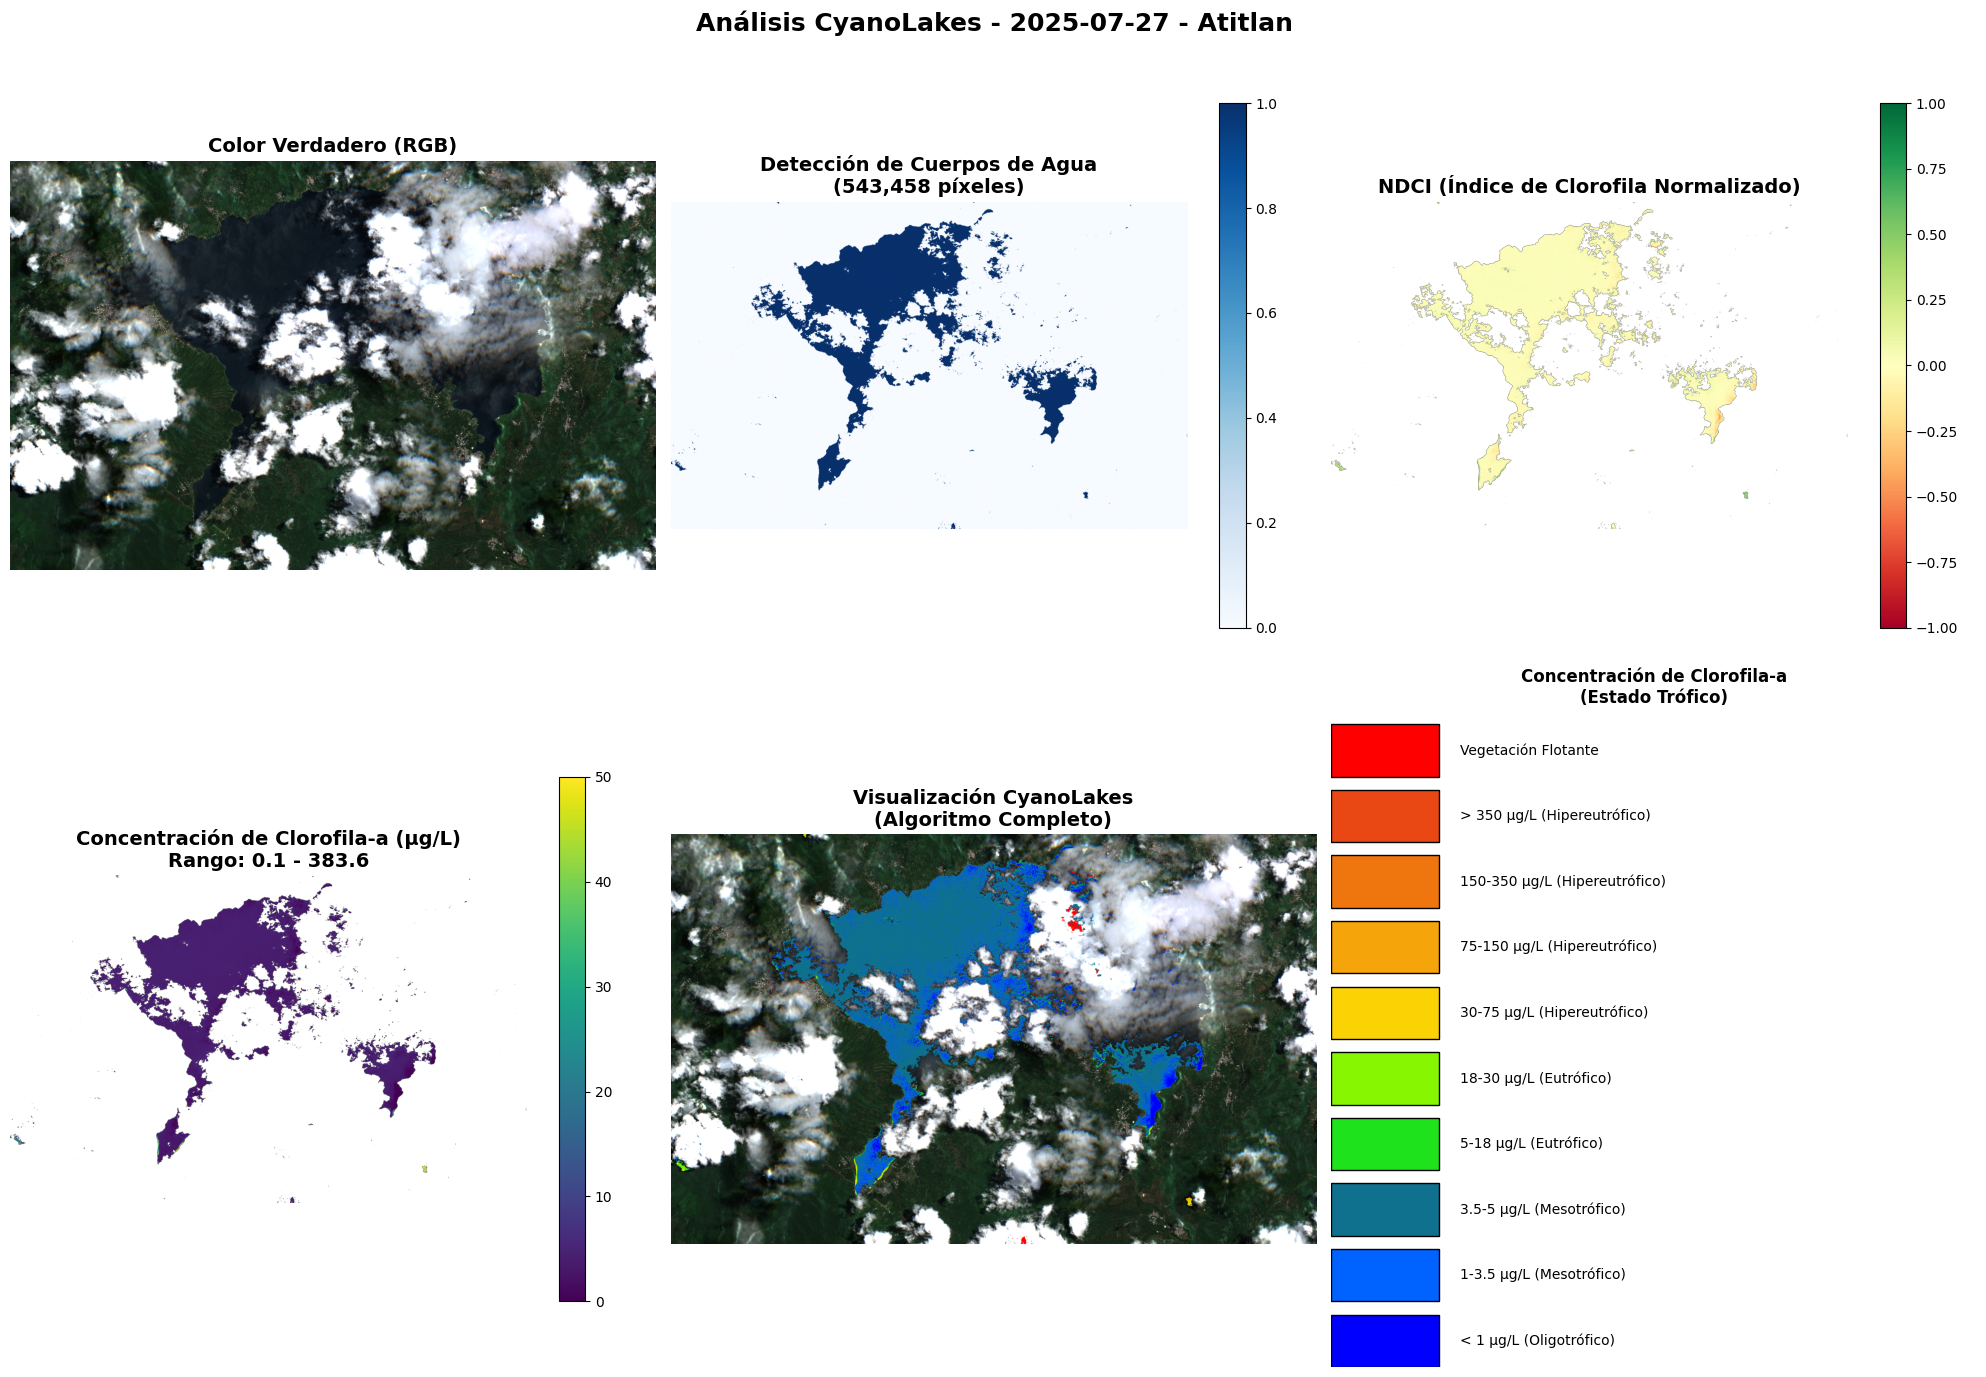


Procesando fecha válida: 2025-03-17 de openEO_2025-03-17Z.tif
  Imagen: 2759x1751, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=680160.0, bottom=1614170.0, right=707750.0, top=1631680.0)
  Índices calculados exitosamente
  Rango NDVI: -69.000 a 25.000
  Rango NDWI: -31.000 a 15.000
  Rango NDCI: -12.333 a 91.000

Procesando fecha válida: 2025-01-26 de openEO_2025-01-26Z.tif
  Imagen: 2759x1751, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=680160.0, bottom=1614170.0, right=707750.0, top=1631680.0)
  Índices calculados exitosamente
  Rango NDVI: -57.000 a 55.000
  Rango NDWI: -2.000 a 4.846
  Rango NDCI: -135.000 a 227.000

Procesando fecha válida: 2025-04-16 de openEO_2025-04-16Z.tif
  Imagen: 2759x1751, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=680160.0, bottom=1614170.0, right=707750.0, top=1631680.0)
  Índices calculados exitosamente
  Rango NDVI: -0.423 a 1.641
  Rango NDWI: -3.806 a 0.284
  Rango NDCI: -1.161 a 2.376

Procesando fecha válida: 2025-

In [2]:
DATA_DIR = "./data/GIS/Atitlan"
atitlan_ndvi, atitlan_ndwi, atitlan_ndci = procesar_todas_las_imagenes(
    DATA_DIR, 
    visualize_date=None,
    process_all_dates=True
)


Fechas disponibles: ['2025-01-03', '2025-01-08', '2025-01-13', '2025-01-18', '2025-01-23', '2025-01-28', '2025-02-02', '2025-02-07', '2025-02-12', '2025-02-17', '2025-02-22', '2025-02-27', '2025-03-04', '2025-03-09', '2025-03-14', '2025-03-19', '2025-03-24', '2025-03-26', '2025-03-29', '2025-04-03', '2025-04-08', '2025-04-13', '2025-04-15', '2025-04-18', '2025-04-23', '2025-04-28', '2025-05-03', '2025-05-05', '2025-05-08', '2025-05-13', '2025-05-18', '2025-05-23', '2025-05-25', '2025-05-28', '2025-06-02', '2025-06-07', '2025-06-12', '2025-06-14', '2025-06-17', '2025-06-22', '2025-06-27', '2025-07-02', '2025-07-04', '2025-07-07', '2025-07-12', '2025-07-17', '2025-07-22', '2025-07-24', '2025-07-27']
Procesando TODAS las fechas disponibles
Visualización para la fecha más reciente: 2025-07-27
Se encontraron 49 archivos .tif

Procesando fecha válida: 2025-05-05 de openEO_2025-05-05Z.tif
  Imagen: 1360x917, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=754570.0, bottom=1594630.0, ri

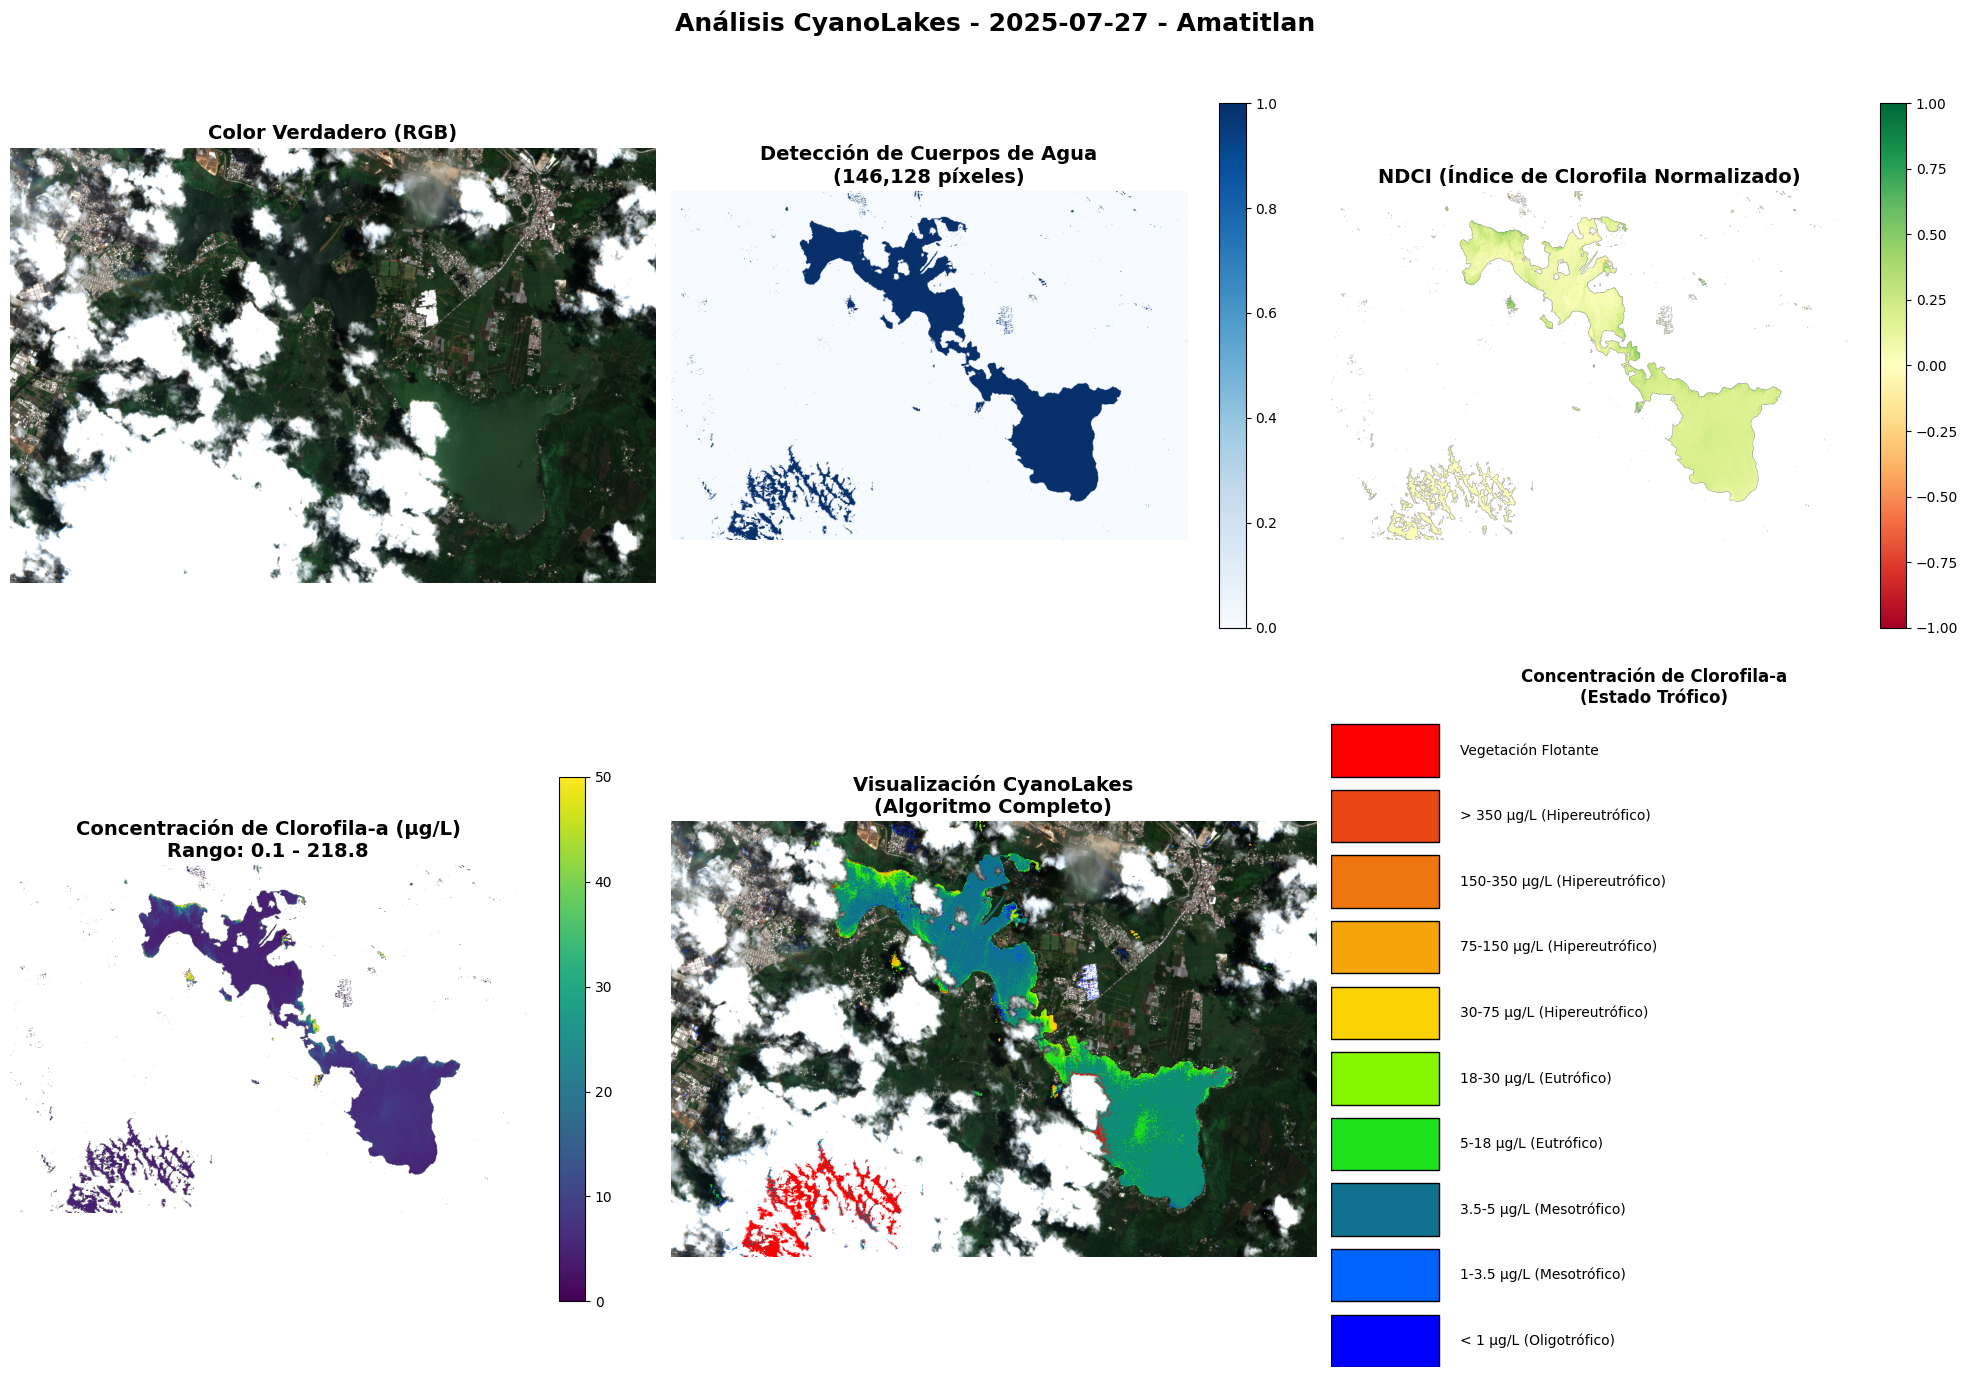


Procesando fecha válida: 2025-01-08 de openEO_2025-01-08Z.tif
  Imagen: 1360x917, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=754570.0, bottom=1594630.0, right=768170.0, top=1603800.0)
  Índices calculados exitosamente
  Rango NDVI: -0.740 a 0.903
  Rango NDWI: -0.793 a 0.817
  Rango NDCI: -0.544 a 0.670

Procesando fecha válida: 2025-02-02 de openEO_2025-02-02Z.tif
  Imagen: 1360x917, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=754570.0, bottom=1594630.0, right=768170.0, top=1603800.0)
  Índices calculados exitosamente
  Rango NDVI: -67.000 a 1.605
  Rango NDWI: -139.000 a 199.000
  Rango NDCI: -185.000 a 199.000

Procesando fecha válida: 2025-05-03 de openEO_2025-05-03Z.tif
  Imagen: 1360x917, 9 bandas
  CRS: EPSG:32615
  Límites: BoundingBox(left=754570.0, bottom=1594630.0, right=768170.0, top=1603800.0)
  Índices calculados exitosamente
  Rango NDVI: -22.333 a 1.039
  Rango NDWI: -1.093 a 1.925
  Rango NDCI: -0.675 a 1.049

Procesando fecha válida: 2025-06-12

In [41]:
AMA_DIR  = "./data/GIS/Amatitlan"
amatitlan_ndvi, amatitlan_ndwi, amatitlan_ndci = procesar_todas_las_imagenes(
    AMA_DIR, 
    visualize_date=None,
    process_all_dates=True
)


## Graficar

Ahora graficamos de nuevo lo mismo que vimos


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def series_y_grafico(index_dict, titulo, y_label, csv_out, png_out, clip_min=-1.0, clip_max=1.0):
    """
    index_dict: dict { 'YYYY-MM-DD': ndarray2D | None }
    titulo:     str  título del gráfico
    y_label:    str  etiqueta del eje Y
    csv_out:    str  ruta del CSV a guardar
    png_out:    str  ruta del PNG a guardar
    clip_min/max:    límites para recortar valores extremos antes de promediar
    """
    rows = []
    for d, arr in index_dict.items():
        if arr is None:
            # p. ej., NDCI ausente si no hubo B05 para esa fecha
            continue
        arr_clip = np.clip(arr.astype(np.float32), clip_min, clip_max)
        rows.append({"date": pd.to_datetime(d), "mean": np.nanmean(arr_clip)})

    if not rows:
        raise ValueError("No hay datos válidos para construir la serie.")

    df = (pd.DataFrame(rows)
            .sort_values("date")
            .set_index("date"))

    # Guardar CSV
    df.to_csv(csv_out)

    # Graficar
    plt.figure(figsize=(9,4))
    plt.plot(df.index, df["mean"], marker="o")
    plt.title(titulo)
    plt.xlabel("Fecha")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(png_out, dpi=150)
    plt.show()

    print(f"Listo: {csv_out} y {png_out} generados.")
    return df  # por si quieres reutilizar la serie en más análisis


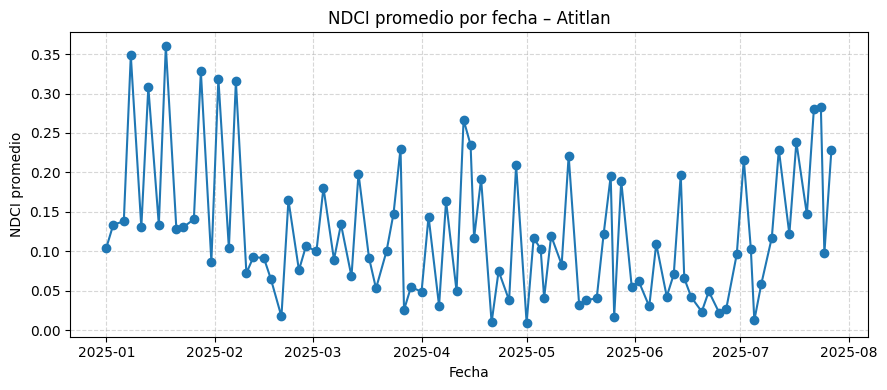

Listo: ndci_mean_timeseries_atitlan.csv y ndci_mean_timeseries_atitlan.png generados.


In [50]:
ndci_df2 = series_y_grafico(
    atitlan_ndci,
    "NDCI promedio por fecha – Atitlan",
    "NDCI promedio",
    "ndci_mean_timeseries_atitlan.csv",
    "ndci_mean_timeseries_atitlan.png",
    clip_min=-0.5, clip_max=0.8 
)

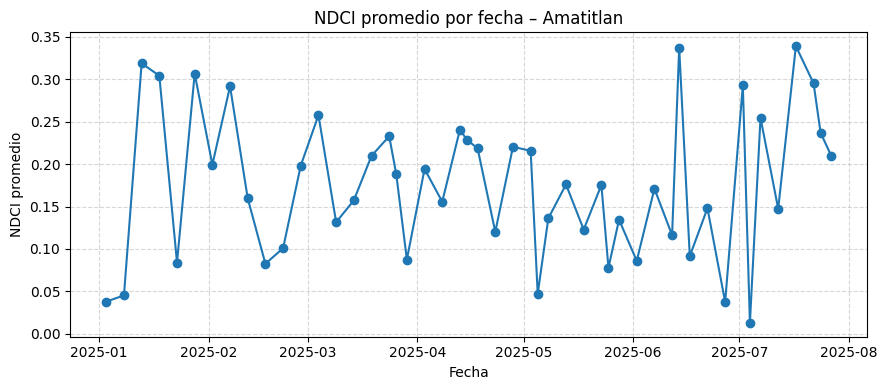

Listo: ndci_mean_timeseries_amatitlan.csv y ndci_mean_timeseries_amatitlan.png generados.


In [51]:
ndci_df1 = series_y_grafico(
    amatitlan_ndci,
    "NDCI promedio por fecha – Amatitlan",
    "NDCI promedio",
    "ndci_mean_timeseries_amatitlan.csv",
    "ndci_mean_timeseries_amatitlan.png",
    clip_min=-0.5, clip_max=0.8 
)

## Parte 10

Ya habiendo arreglado lo de anterior. Vamos a hacer una serie de tiempo para predecir el índice de cianobacteria.

Para eso antes normalizamos




Leemos los csv y los convertimos a dataframes

## Atitlan

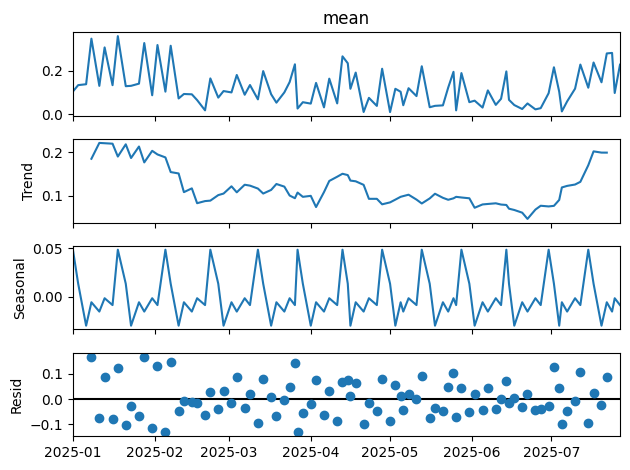

In [62]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

csv_path = "ndci_mean_timeseries_atitlan.csv"
df_atitlan = pd.read_csv(csv_path, parse_dates=["date"])

df_atitlan.set_index('date', inplace=True)


descomposicion = seasonal_decompose(df_atitlan['mean'], model='additive', period=7)  # ajusta period según tu estacionalidad


descomposicion.plot()
plt.show()


## Amatitlan

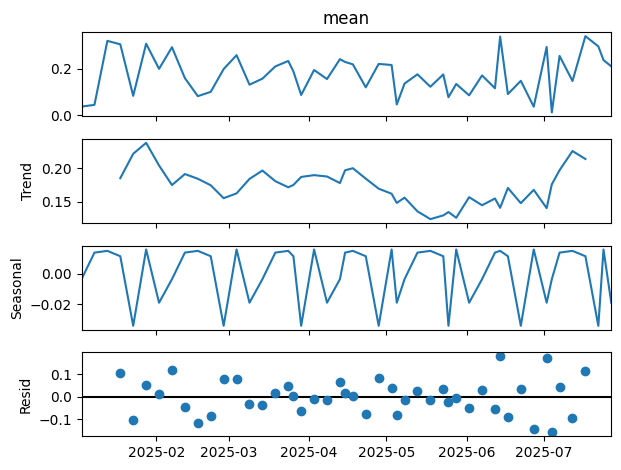

In [63]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

csv_path = "ndci_mean_timeseries_amatitlan.csv"
df_amatitlan = pd.read_csv(csv_path, parse_dates=["date"])

df_amatitlan.set_index('date', inplace=True)


descomposicion = seasonal_decompose(df_amatitlan['mean'], model='additive', period=7)  # ajusta period según tu estacionalidad


descomposicion.plot()
plt.show()


Ahora vamos a hacer el test de fuller


Amatitlan

In [64]:
from statsmodels.tsa.stattools import adfuller

print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(df_amatitlan, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba        -4.930482
p-value                       0.000030
# de retardos usados          1.000000
# de observaciones usadas    47.000000
Critical Value (1%)          -3.577848
Critical Value (5%)          -2.925338
Critical Value (10%)         -2.600774
dtype: float64


Atitlan

In [65]:
from statsmodels.tsa.stattools import adfuller

print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(df_atitlan, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba        -4.187905
p-value                       0.000691
# de retardos usados          1.000000
# de observaciones usadas    89.000000
Critical Value (1%)          -3.506057
Critical Value (5%)          -2.894607
Critical Value (10%)         -2.584410
dtype: float64


Ambas series pasaron la prueba de Dickey-Fuller. Esto significa que no necesitamos diferenciarlas para modelado ARIMA

Dividimos en datos de prueba y entrenamiento

In [66]:
import numpy as np
import pandas as pd


def split_train_test(series, test_ratio=0.2):
    """
    Divide una serie temporal en entrenamiento y prueba según test_ratio
    """
    n = len(series)
    test_size = int(n * test_ratio)
    train_size = n - test_size
    
    train = series[:train_size].values.reshape(-1, 1)
    test = series[train_size:].values.reshape(-1, 1)
    
    return train, test


train_atitlan, test_atitlan = split_train_test(df_atitlan['mean'], test_ratio=0.2)
print(f"Atitlán -> Train: {len(train_atitlan)}, Test: {len(test_atitlan)}")

train_amatitlan, test_amatitlan = split_train_test(df_amatitlan['mean'], test_ratio=0.2)
print(f"Amatitlán -> Train: {len(train_amatitlan)}, Test: {len(test_amatitlan)}")


Atitlán -> Train: 73, Test: 18
Amatitlán -> Train: 40, Test: 9


In [71]:
import numpy as np

# Función para dividir en train, validation y test
def split_train_val_test(series, train_ratio=0.6, val_ratio=0.2):
    n = len(series)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    
    train = series[:train_end].values.reshape(-1,1)
    val = series[train_end:val_end].values.reshape(-1,1)
    test = series[val_end:].values.reshape(-1,1)
    
    return train, val, test

# Dividir las series
train_atitlan, val_atitlan, test_atitlan = split_train_val_test(df_atitlan['mean'])
train_amatitlan, val_amatitlan, test_amatitlan = split_train_val_test(df_amatitlan['mean'])

# Función para pasar a formato supervisado
def supervisada(serie, retrasos=1):
    serie_x = []
    serie_y = []
    for i in range(len(serie)-retrasos):
        valor = serie[i:(i+retrasos),0]
        valor_sig = serie[i+retrasos,0]
        serie_x.append(valor)
        serie_y.append(valor_sig)
    return np.array(serie_x), np.array(serie_y)

# Convertir a supervisado
x_train_atitlan, y_train_atitlan = supervisada(train_atitlan)
x_val_atitlan, y_val_atitlan = supervisada(val_atitlan)
x_test_atitlan, y_test_atitlan = supervisada(test_atitlan)

x_train_amatitlan, y_train_amatitlan = supervisada(train_amatitlan)
x_val_amatitlan, y_val_amatitlan = supervisada(val_amatitlan)
x_test_amatitlan, y_test_amatitlan = supervisada(test_amatitlan)

# Reshape para LSTM (samples, timesteps, features)
x_train_atitlan = x_train_atitlan.reshape((x_train_atitlan.shape[0], 1, 1))
x_val_atitlan = x_val_atitlan.reshape((x_val_atitlan.shape[0], 1, 1))
x_test_atitlan = x_test_atitlan.reshape((x_test_atitlan.shape[0], 1, 1))

x_train_amatitlan = x_train_amatitlan.reshape((x_train_amatitlan.shape[0], 1, 1))
x_val_amatitlan = x_val_amatitlan.reshape((x_val_amatitlan.shape[0], 1, 1))
x_test_amatitlan = x_test_amatitlan.reshape((x_test_amatitlan.shape[0], 1, 1))

# Verificar tamaños
print(f"Atitlán -> x_train: {x_train_atitlan.shape}, x_val: {x_val_atitlan.shape}, x_test: {x_test_atitlan.shape}")
print(f"Amatitlán -> x_train: {x_train_amatitlan.shape}, x_val: {x_val_amatitlan.shape}, x_test: {x_test_amatitlan.shape}")


Atitlán -> x_train: (53, 1, 1), x_val: (17, 1, 1), x_test: (18, 1, 1)
Amatitlán -> x_train: (28, 1, 1), x_val: (8, 1, 1), x_test: (10, 1, 1)


Ahora predecimos

🏞️ === ANÁLISIS Y PREDICCIÓN ARIMA PARA LAGOS ===
🚀 Iniciando predicciones ARIMA mejoradas...

🏔️ === PREDICCIÓN ARIMA MEJORADA PARA LAGO AMATITLÁN ===
📈 Análisis inicial de la serie:
   Puntos totales: 49
   Rango: 0.012874 a 0.338951
   Media: 0.176162, Std: 0.086008
   Valores cercanos a cero (<0.01): 0
📈 División de datos (serie transformada):
   Train: 29 puntos
   Val:   9 puntos
   Test:  11 puntos

📊 Test de Estacionariedad para Lago Amatitlán - Entrenamiento:
ADF Statistic: -4.585270
p-value: 0.000137
Critical Values:
	1%: -3.788
	5%: -3.013
	10%: -2.646
✅ La serie es ESTACIONARIA (p-value <= 0.05)

🔍 Búsqueda de mejores parámetros ARIMA...
   Tamaño de entrenamiento: 29 puntos
   ⚠️ Muestra pequeña, usando parámetros máximos: p=2, d=2, q=2
   Intentos totales: 27, Exitosos: 27
✅ Mejores parámetros encontrados: ARIMA(0, 0, 2)
   AIC: -63.90

🔮 Generando predicciones mejoradas...

📊 MÉTRICAS DE RENDIMIENTO:
🟠 VALIDACIÓN:
   RMSE: 0.105377
   MAE:  0.093441
   MAPE: 73.77%
   MP

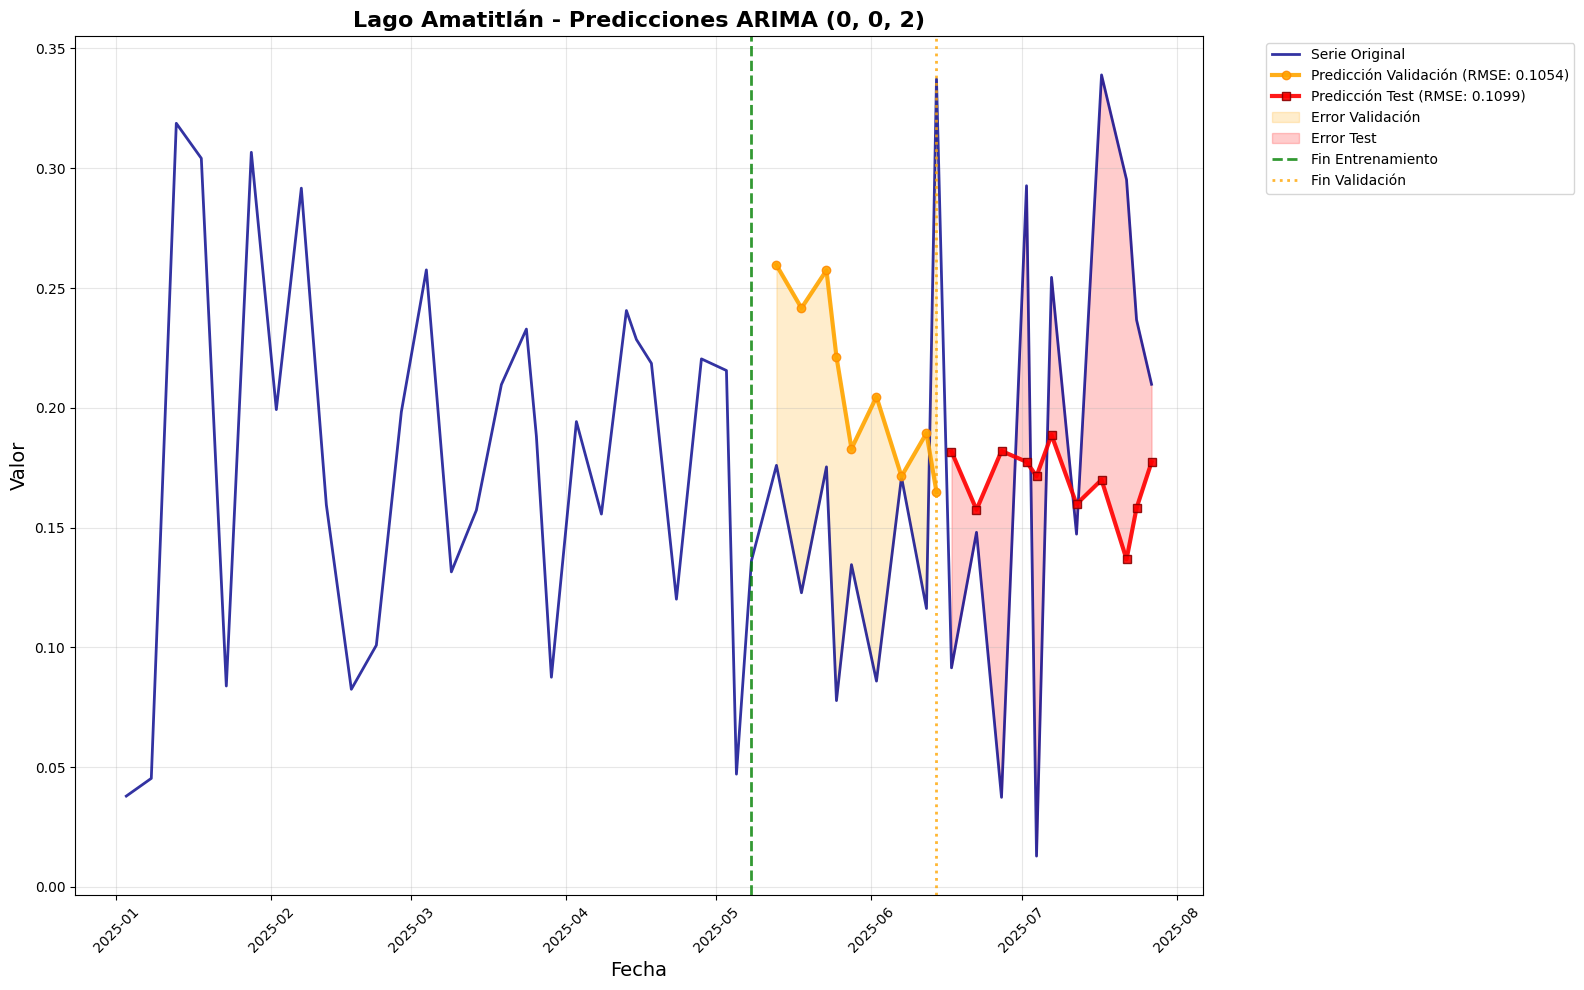


🏔️ === PREDICCIÓN ARIMA MEJORADA PARA LAGO ATITLÁN ===
📈 Análisis inicial de la serie:
   Puntos totales: 91
   Rango: 0.009318 a 0.360057
   Media: 0.124271, Std: 0.087194
   Valores cercanos a cero (<0.01): 2
📈 División de datos (serie transformada):
   Train: 54 puntos
   Val:   18 puntos
   Test:  19 puntos

📊 Test de Estacionariedad para Lago Atitlán - Entrenamiento:
ADF Statistic: -3.126522
p-value: 0.024652
Critical Values:
	1%: -3.563
	5%: -2.919
	10%: -2.597
✅ La serie es ESTACIONARIA (p-value <= 0.05)

🔍 Búsqueda de mejores parámetros ARIMA...
   Tamaño de entrenamiento: 54 puntos
   Intentos totales: 48, Exitosos: 48
✅ Mejores parámetros encontrados: ARIMA(2, 0, 0)
   AIC: -111.03

🔮 Generando predicciones mejoradas...

📊 MÉTRICAS DE RENDIMIENTO:
🟠 VALIDACIÓN:
   RMSE: 0.071697
   MAE:  0.059808
   MAPE: 123.34%
   MPE:  -101.61% (sesgo direccional)
   SMAPE: 62.51% (simétrico)
   Valores reales - Min: 0.0173, Max: 0.2211
   Predicciones   - Min: 0.0797, Max: 0.1783
🔴 TEST:

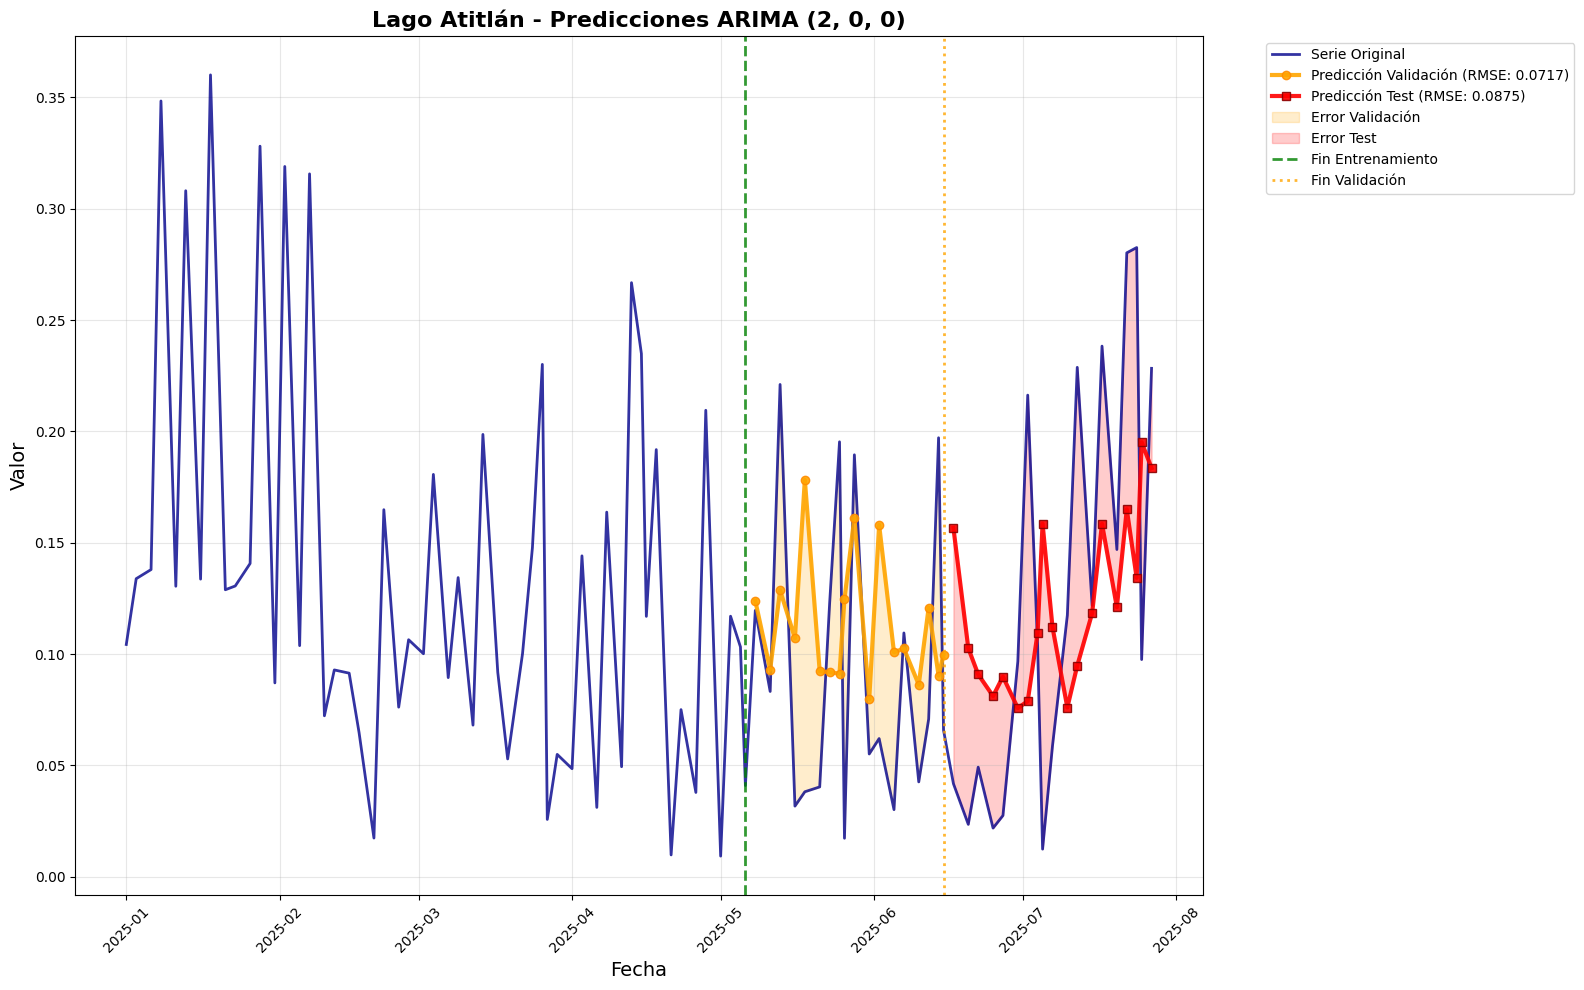


🎉 === RESUMEN FINAL ===
🏞️ Amatitlán - Modelo ARIMA(0, 0, 2)
   Predicciones Val: 9
   Predicciones Test: 11
🏔️ Atitlán - Modelo ARIMA(2, 0, 0)
   Predicciones Val: 18
   Predicciones Test: 19

✅ Las variables de predicción están ahora disponibles:
   - prediccion_val_amatitlan
   - prediccion_test_amatitlan
   - prediccion_val_atitlan
   - prediccion_test_atitlan

Puedes usar ahora el código de visualización que tenías!


In [ ]:
# PREDICCIONES CON ARIMA PARA LAGOS DE GUATEMALA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("🏞️ === ANÁLISIS Y PREDICCIÓN ARIMA PARA LAGOS ===")

def test_stationarity(timeseries, title):
    """
    Prueba de estacionariedad usando test de Dickey-Fuller
    """
    print(f'\n📊 Test de Estacionariedad para {title}:')
    
    # Test de Dickey-Fuller
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("✅ La serie es ESTACIONARIA (p-value <= 0.05)")
    else:
        print("❌ La serie NO es estacionaria (p-value > 0.05)")
        print("   Se recomienda diferenciación")
    
    return result[1] <= 0.05

def find_best_arima_params(train_data, max_p=3, max_d=2, max_q=3):
    """
    Búsqueda automática de los mejores parámetros ARIMA usando AIC
    Parámetros más conservadores para series pequeñas
    """
    print("\n🔍 Búsqueda de mejores parámetros ARIMA...")
    print(f"   Tamaño de entrenamiento: {len(train_data)} puntos")
    
    # Ajustar parámetros máximos según el tamaño de la muestra
    n = len(train_data)
    if n < 50:
        max_p = min(max_p, 2)
        max_q = min(max_q, 2)
        print(f"   ⚠️ Muestra pequeña, usando parámetros máximos: p={max_p}, d={max_d}, q={max_q}")
    
    best_aic = np.inf
    best_params = None
    best_model = None
    attempts = 0
    successful_fits = 0
    
    # Grid search
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                attempts += 1
                try:
                    model = ARIMA(train_data, order=(p, d, q))
                    fitted_model = model.fit()
                    successful_fits += 1
                    
                    if fitted_model.aic < best_aic:
                        best_aic = fitted_model.aic
                        best_params = (p, d, q)
                        best_model = fitted_model
                        
                except Exception as e:
                    continue
    
    print(f"   Intentos totales: {attempts}, Exitosos: {successful_fits}")
    
    if best_model is None:
        print("   ❌ No se encontró ningún modelo válido, usando ARIMA(1,1,1) por defecto")
        try:
            model = ARIMA(train_data, order=(1, 1, 1))
            best_model = model.fit()
            best_params = (1, 1, 1)
            best_aic = best_model.aic
        except:
            print("   ❌ Incluso ARIMA(1,1,1) falló, usando ARIMA(0,1,0)")
            model = ARIMA(train_data, order=(0, 1, 0))
            best_model = model.fit()
            best_params = (0, 1, 0)
            best_aic = best_model.aic
    
    print(f"✅ Mejores parámetros encontrados: ARIMA{best_params}")
    print(f"   AIC: {best_aic:.2f}")
    
    return best_params, best_model

def split_train_val_test_arima(series, train_ratio=0.6, val_ratio=0.2):
    """
    División específica para ARIMA manteniendo el índice temporal
    """
    n = len(series)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    
    train = series[:train_end]
    val = series[train_end:val_end]
    test = series[val_end:]
    
    return train, val, test

def predict_arima_with_validation(series, lake_name):
    """
    Versión mejorada con múltiples estrategias para manejar MAPE alto
    """
    print(f"\n🏔️ === PREDICCIÓN ARIMA MEJORADA PARA {lake_name.upper()} ===")
    
    # Análisis inicial de la serie
    print(f"📈 Análisis inicial de la serie:")
    print(f"   Puntos totales: {len(series)}")
    print(f"   Rango: {series.min():.6f} a {series.max():.6f}")
    print(f"   Media: {series.mean():.6f}, Std: {series.std():.6f}")
    print(f"   Valores cercanos a cero (<0.01): {np.sum(np.abs(series) < 0.01)}")
    
    # Detectar si necesitamos transformación
    needs_transformation = False
    transformation_type = "none"
    
    if series.min() <= 0:
        print("   ⚠️ Serie contiene valores <= 0, no se puede aplicar log")
    elif series.max() / series.min() > 100:  # Gran rango dinámico
        needs_transformation = True
        transformation_type = "log"
        print("   📊 Gran rango dinámico detectado, aplicando transformación log")
    elif np.std(series) / np.mean(series) > 1:  # Alta variabilidad relativa
        needs_transformation = True
        transformation_type = "sqrt"
        print("   📊 Alta variabilidad relativa, aplicando transformación sqrt")
    
    # Aplicar transformación si es necesaria
    if needs_transformation:
        if transformation_type == "log":
            # Agregar constante pequeña para evitar log(0)
            min_val = series.min()
            if min_val <= 0:
                offset = abs(min_val) + 0.001
                transformed_series = np.log(series + offset)
                print(f"   Aplicando log(x + {offset})")
            else:
                transformed_series = np.log(series)
                offset = 0
                print("   Aplicando log(x)")
        elif transformation_type == "sqrt":
            min_val = series.min()
            if min_val < 0:
                offset = abs(min_val) + 0.001
                transformed_series = np.sqrt(series + offset)
                print(f"   Aplicando sqrt(x + {offset})")
            else:
                transformed_series = np.sqrt(series)
                offset = 0
                print("   Aplicando sqrt(x)")
        
        series_to_model = pd.Series(transformed_series, index=series.index)
    else:
        series_to_model = series.copy()
        offset = 0
    
    # Dividir los datos
    train, val, test = split_train_val_test_arima(series_to_model)
    
    print(f"📈 División de datos (serie transformada):")
    print(f"   Train: {len(train)} puntos")
    print(f"   Val:   {len(val)} puntos") 
    print(f"   Test:  {len(test)} puntos")
    
    # Test de estacionariedad
    is_stationary = test_stationarity(train.values, f"{lake_name} - Entrenamiento")
    
    # Encontrar mejores parámetros
    best_params, best_model = find_best_arima_params(train.values)
    
    if best_model is None:
        print("❌ No se pudo encontrar un modelo ARIMA válido")
        return None, None, None
    
    # Predicciones (en escala transformada)
    print("\n🔮 Generando predicciones mejoradas...")
    pred_val_transformed = []
    pred_test_transformed = []
    
    # Predicciones de validación
    history = train.values.copy()
    for i in range(len(val)):
        temp_model = ARIMA(history, order=best_params)
        temp_fitted = temp_model.fit()
        forecast = temp_fitted.forecast(steps=1)[0]
        pred_val_transformed.append(forecast)
        history = np.append(history, val.iloc[i])
    
    # Predicciones de test
    history = np.concatenate([train.values, val.values])
    for i in range(len(test)):
        temp_model = ARIMA(history, order=best_params)
        temp_fitted = temp_model.fit()
        forecast = temp_fitted.forecast(steps=1)[0]
        pred_test_transformed.append(forecast)
        history = np.append(history, test.iloc[i])
    
    pred_val_transformed = np.array(pred_val_transformed)
    pred_test_transformed = np.array(pred_test_transformed)
    
    # Transformación inversa
    if needs_transformation:
        print(f"🔄 Aplicando transformación inversa ({transformation_type})")
        if transformation_type == "log":
            pred_val = np.exp(pred_val_transformed) - offset
            pred_test = np.exp(pred_test_transformed) - offset
        elif transformation_type == "sqrt":
            pred_val = pred_val_transformed**2 - offset
            pred_test = pred_test_transformed**2 - offset
    else:
        pred_val = pred_val_transformed.copy()
        pred_test = pred_test_transformed.copy()
    
    # Obtener valores originales para métricas
    train_orig, val_orig, test_orig = split_train_val_test_arima(series)
    
    # Calcular métricas con la versión mejorada
    print("\n📊 MÉTRICAS DE RENDIMIENTO:")
    
    # Validación
    rmse_val = np.sqrt(mean_squared_error(val_orig.values, pred_val))
    mae_val = mean_absolute_error(val_orig.values, pred_val)
    
    # MAPE mejorado con manejo de valores cercanos a cero
    def safe_mape(y_true, y_pred, epsilon=1e-8):
        """MAPE que maneja valores cercanos a cero"""
        mask = np.abs(y_true) > epsilon
        if np.sum(mask) == 0:
            return np.inf
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    mape_val = safe_mape(val_orig.values, pred_val)
    
    # Métricas adicionales
    def mean_percentage_error(y_true, y_pred):
        """Error porcentual promedio (puede ser negativo)"""
        return np.mean((y_true - y_pred) / y_true) * 100
    
    def symmetric_mape(y_true, y_pred):
        """MAPE simétrico - más robusto"""
        return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    
    mpe_val = mean_percentage_error(val_orig.values, pred_val)
    smape_val = symmetric_mape(val_orig.values, pred_val)
    
    print(f"🟠 VALIDACIÓN:")
    print(f"   RMSE: {rmse_val:.6f}")
    print(f"   MAE:  {mae_val:.6f}")
    print(f"   MAPE: {mape_val:.2f}%")
    print(f"   MPE:  {mpe_val:.2f}% (sesgo direccional)")
    print(f"   SMAPE: {smape_val:.2f}% (simétrico)")
    print(f"   Valores reales - Min: {val_orig.values.min():.4f}, Max: {val_orig.values.max():.4f}")
    print(f"   Predicciones   - Min: {pred_val.min():.4f}, Max: {pred_val.max():.4f}")
    
    # Test
    rmse_test = np.sqrt(mean_squared_error(test_orig.values, pred_test))
    mae_test = mean_absolute_error(test_orig.values, pred_test)
    mape_test = safe_mape(test_orig.values, pred_test)
    mpe_test = mean_percentage_error(test_orig.values, pred_test)
    smape_test = symmetric_mape(test_orig.values, pred_test)
    
    print(f"🔴 TEST:")
    print(f"   RMSE: {rmse_test:.6f}")
    print(f"   MAE:  {mae_test:.6f}")
    print(f"   MAPE: {mape_test:.2f}%")
    print(f"   MPE:  {mpe_test:.2f}% (sesgo direccional)")
    print(f"   SMAPE: {smape_test:.2f}% (simétrico)")
    print(f"   Valores reales - Min: {test_orig.values.min():.4f}, Max: {test_orig.values.max():.4f}")
    print(f"   Predicciones   - Min: {pred_test.min():.4f}, Max: {pred_test.max():.4f}")
    
    # Diagnóstico de problemas
    print(f"\n🔍 DIAGNÓSTICO DE PROBLEMAS:")
    
    # Verificar si hay valores cercanos a cero
    val_near_zero = np.sum(np.abs(val_orig.values) < 0.01)
    test_near_zero = np.sum(np.abs(test_orig.values) < 0.01)
    pred_val_near_zero = np.sum(np.abs(pred_val) < 0.01)
    pred_test_near_zero = np.sum(np.abs(pred_test) < 0.01)
    
    print(f"   Valores cercanos a cero (<0.01):")
    print(f"     Val reales: {val_near_zero}/{len(val_orig)}, Pred val: {pred_val_near_zero}/{len(pred_val)}")
    print(f"     Test reales: {test_near_zero}/{len(test_orig)}, Pred test: {pred_test_near_zero}/{len(pred_test)}")
    
    # Verificar cambio de signo
    val_sign_changes = np.sum((val_orig.values > 0) != (pred_val > 0))
    test_sign_changes = np.sum((test_orig.values > 0) != (pred_test > 0))
    
    print(f"   Cambios de signo (real vs predicción):")
    print(f"     Validación: {val_sign_changes}/{len(val_orig)} ({val_sign_changes/len(val_orig)*100:.1f}%)")
    print(f"     Test: {test_sign_changes}/{len(test_orig)} ({test_sign_changes/len(test_orig)*100:.1f}%)")
    
    # Análisis de la magnitud del error
    val_rel_errors = np.abs((val_orig.values - pred_val) / val_orig.values)
    test_rel_errors = np.abs((test_orig.values - pred_test) / test_orig.values)
    
    print(f"   Distribución de errores relativos:")
    print(f"     Val - Mediana: {np.median(val_rel_errors)*100:.1f}%, P90: {np.percentile(val_rel_errors, 90)*100:.1f}%")
    print(f"     Test - Mediana: {np.median(test_rel_errors)*100:.1f}%, P90: {np.percentile(test_rel_errors, 90)*100:.1f}%")
    
    # Recomendaciones
    if mape_test > 50:
        print(f"\n⚠️ MAPE muy alto ({mape_test:.1f}%). Posibles causas:")
        if val_near_zero > 0 or test_near_zero > 0:
            print("   • Valores reales muy cercanos a cero (problemático para MAPE)")
        if test_sign_changes > len(test_orig) * 0.2:
            print("   • Muchos cambios de signo entre real y predicción")
        if np.std(test_orig.values) / np.mean(np.abs(test_orig.values)) > 0.5:
            print("   • Serie muy volátil para el modelo")
        print("   Considera usar SMAPE en lugar de MAPE, o transformar los datos")
    
    # Gráfico de resultados usando valores originales
    plt.figure(figsize=(16, 10))
    
    # Serie original completa
    plt.plot(series.index, series.values, 
             label='Serie Original', color='darkblue', linewidth=2, alpha=0.8)
    
    # Predicciones de validación
    plt.plot(val_orig.index, pred_val, 
             'o-', color='orange', linewidth=3, markersize=6,
             label=f'Predicción Validación (RMSE: {rmse_val:.4f})', 
             alpha=0.9, markeredgecolor='darkorange')
    
    # Predicciones de test
    plt.plot(test_orig.index, pred_test, 
             's-', color='red', linewidth=3, markersize=6,
             label=f'Predicción Test (RMSE: {rmse_test:.4f})', 
             alpha=0.9, markeredgecolor='darkred')
    
    # Áreas de error
    plt.fill_between(val_orig.index, val_orig.values, pred_val, 
                     color='orange', alpha=0.2, label='Error Validación')
    plt.fill_between(test_orig.index, test_orig.values, pred_test, 
                     color='red', alpha=0.2, label='Error Test')
    
    # Líneas divisorias
    plt.axvline(x=train_orig.index[-1], color='green', 
                linestyle='--', linewidth=2, alpha=0.8, 
                label='Fin Entrenamiento')
    plt.axvline(x=val_orig.index[-1], color='orange', 
                linestyle=':', linewidth=2, alpha=0.8, 
                label='Fin Validación')
    
    # Título con información de transformación
    title = f'{lake_name} - Predicciones ARIMA {best_params}'
    if needs_transformation:
        title += f' (Transf: {transformation_type})'
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Fecha', fontsize=14)
    plt.ylabel('Valor', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return pred_val, pred_test, best_params, {
        'transformation': transformation_type,
        'offset': offset,
        'train_orig': train_orig,
        'val_orig': val_orig, 
        'test_orig': test_orig
    }
    """
    Función principal para predicción ARIMA con validación
    """
    print(f"\n🏔️ === PREDICCIÓN ARIMA PARA {lake_name.upper()} ===")
    
    # Dividir los datos
    train, val, test = split_train_val_test_arima(series)
    
    print(f"📈 División de datos:")
    print(f"   Train: {len(train)} puntos ({train.index[0]} a {train.index[-1]})")
    print(f"   Val:   {len(val)} puntos ({val.index[0]} a {val.index[-1]})")
    print(f"   Test:  {len(test)} puntos ({test.index[0]} a {test.index[-1]})")
    
    # Test de estacionariedad
    is_stationary = test_stationarity(train.values, f"{lake_name} - Entrenamiento")
    
    # Encontrar mejores parámetros
    best_params, best_model = find_best_arima_params(train.values)
    
    if best_model is None:
        print("❌ No se pudo encontrar un modelo ARIMA válido")
        return None, None, None
    
    print(f"\n📋 Resumen del modelo:")
    print(best_model.summary().tables[1])
    
    # Predicciones para validación
    print("\n🔮 Generando predicciones de validación...")
    pred_val = []
    
    # Usar datos de entrenamiento para predecir validación paso a paso
    history = train.values.copy()
    
    for i in range(len(val)):
        # Entrenar modelo con historia actual
        temp_model = ARIMA(history, order=best_params)
        temp_fitted = temp_model.fit()
        
        # Predecir siguiente punto
        forecast = temp_fitted.forecast(steps=1)[0]
        pred_val.append(forecast)
        
        # Actualizar historia con valor real (para siguiente predicción)
        history = np.append(history, val.iloc[i])
    
    pred_val = np.array(pred_val)
    
    # Predicciones para test
    print("🔮 Generando predicciones de test...")
    pred_test = []
    
    # Usar datos de entrenamiento + validación para predecir test
    history = np.concatenate([train.values, val.values])
    
    for i in range(len(test)):
        # Entrenar modelo con historia actual
        temp_model = ARIMA(history, order=best_params)
        temp_fitted = temp_model.fit()
        
        # Predecir siguiente punto
        forecast = temp_fitted.forecast(steps=1)[0]
        pred_test.append(forecast)
        
        # Actualizar historia con valor real
        history = np.append(history, test.iloc[i])
    
    pred_test = np.array(pred_test)
    
    # Calcular métricas
    print("\n📊 MÉTRICAS DE RENDIMIENTO:")
    
    # Validación
    rmse_val = np.sqrt(mean_squared_error(val.values, pred_val))
    mae_val = mean_absolute_error(val.values, pred_val)
    
    # MAPE mejorado con manejo de valores cercanos a cero
    def safe_mape(y_true, y_pred, epsilon=1e-8):
        """MAPE que maneja valores cercanos a cero"""
        mask = np.abs(y_true) > epsilon
        if np.sum(mask) == 0:
            return np.inf
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    mape_val = safe_mape(val.values, pred_val)
    
    # Métricas adicionales
    def mean_percentage_error(y_true, y_pred):
        """Error porcentual promedio (puede ser negativo)"""
        return np.mean((y_true - y_pred) / y_true) * 100
    
    def symmetric_mape(y_true, y_pred):
        """MAPE simétrico - más robusto"""
        return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    
    mpe_val = mean_percentage_error(val.values, pred_val)
    smape_val = symmetric_mape(val.values, pred_val)
    
    print(f"🟠 VALIDACIÓN:")
    print(f"   RMSE: {rmse_val:.6f}")
    print(f"   MAE:  {mae_val:.6f}")
    print(f"   MAPE: {mape_val:.2f}%")
    print(f"   MPE:  {mpe_val:.2f}% (sesgo direccional)")
    print(f"   SMAPE: {smape_val:.2f}% (simétrico)")
    print(f"   Valores reales - Min: {val.values.min():.4f}, Max: {val.values.max():.4f}")
    print(f"   Predicciones   - Min: {pred_val.min():.4f}, Max: {pred_val.max():.4f}")
    
    # Test
    rmse_test = np.sqrt(mean_squared_error(test.values, pred_test))
    mae_test = mean_absolute_error(test.values, pred_test)
    mape_test = safe_mape(test.values, pred_test)
    mpe_test = mean_percentage_error(test.values, pred_test)
    smape_test = symmetric_mape(test.values, pred_test)
    
    print(f"🔴 TEST:")
    print(f"   RMSE: {rmse_test:.6f}")
    print(f"   MAE:  {mae_test:.6f}")
    print(f"   MAPE: {mape_test:.2f}%")
    print(f"   MPE:  {mpe_test:.2f}% (sesgo direccional)")
    print(f"   SMAPE: {smape_test:.2f}% (simétrico)")
    print(f"   Valores reales - Min: {test.values.min():.4f}, Max: {test.values.max():.4f}")
    print(f"   Predicciones   - Min: {pred_test.min():.4f}, Max: {pred_test.max():.4f}")
    
    # Diagnóstico de problemas
    print(f"\n🔍 DIAGNÓSTICO DE PROBLEMAS:")
    
    # Verificar si hay valores cercanos a cero
    val_near_zero = np.sum(np.abs(val.values) < 0.01)
    test_near_zero = np.sum(np.abs(test.values) < 0.01)
    pred_val_near_zero = np.sum(np.abs(pred_val) < 0.01)
    pred_test_near_zero = np.sum(np.abs(pred_test) < 0.01)
    
    print(f"   Valores cercanos a cero (<0.01):")
    print(f"     Val reales: {val_near_zero}/{len(val)}, Pred val: {pred_val_near_zero}/{len(pred_val)}")
    print(f"     Test reales: {test_near_zero}/{len(test)}, Pred test: {pred_test_near_zero}/{len(pred_test)}")
    
    # Verificar cambio de signo
    val_sign_changes = np.sum((val.values > 0) != (pred_val > 0))
    test_sign_changes = np.sum((test.values > 0) != (pred_test > 0))
    
    print(f"   Cambios de signo (real vs predicción):")
    print(f"     Validación: {val_sign_changes}/{len(val)} ({val_sign_changes/len(val)*100:.1f}%)")
    print(f"     Test: {test_sign_changes}/{len(test)} ({test_sign_changes/len(test)*100:.1f}%)")
    
    # Análisis de la magnitud del error
    val_rel_errors = np.abs((val.values - pred_val) / val.values)
    test_rel_errors = np.abs((test.values - pred_test) / test.values)
    
    print(f"   Distribución de errores relativos:")
    print(f"     Val - Mediana: {np.median(val_rel_errors)*100:.1f}%, P90: {np.percentile(val_rel_errors, 90)*100:.1f}%")
    print(f"     Test - Mediana: {np.median(test_rel_errors)*100:.1f}%, P90: {np.percentile(test_rel_errors, 90)*100:.1f}%")
    
    # Recomendaciones
    if mape_test > 50:
        print(f"\n⚠️ MAPE muy alto ({mape_test:.1f}%). Posibles causas:")
        if val_near_zero > 0 or test_near_zero > 0:
            print("   • Valores reales muy cercanos a cero (problemático para MAPE)")
        if test_sign_changes > len(test) * 0.2:
            print("   • Muchos cambios de signo entre real y predicción")
        if np.std(test.values) / np.mean(np.abs(test.values)) > 0.5:
            print("   • Serie muy volátil para el modelo")
        print("   Considera usar SMAPE en lugar de MAPE, o transformar los datos")
    
    # Gráfico de resultados
    plt.figure(figsize=(16, 10))
    
    # Serie original completa
    plt.plot(series.index, series.values, 
             label='Serie Original', color='darkblue', linewidth=2, alpha=0.8)
    
    # Predicciones de validación
    plt.plot(val.index, pred_val, 
             'o-', color='orange', linewidth=3, markersize=6,
             label=f'Predicción Validación (RMSE: {rmse_val:.4f})', 
             alpha=0.9, markeredgecolor='darkorange')
    
    # Predicciones de test
    plt.plot(test.index, pred_test, 
             's-', color='red', linewidth=3, markersize=6,
             label=f'Predicción Test (RMSE: {rmse_test:.4f})', 
             alpha=0.9, markeredgecolor='darkred')
    
    # Áreas de error
    plt.fill_between(val.index, val.values, pred_val, 
                     color='orange', alpha=0.2, label='Error Validación')
    plt.fill_between(test.index, test.values, pred_test, 
                     color='red', alpha=0.2, label='Error Test')
    
    # Líneas divisorias
    plt.axvline(x=train.index[-1], color='green', 
                linestyle='--', linewidth=2, alpha=0.8, 
                label='Fin Entrenamiento')
    plt.axvline(x=val.index[-1], color='orange', 
                linestyle=':', linewidth=2, alpha=0.8, 
                label='Fin Validación')
    
    # Sombrear regiones
    plt.axvspan(series.index[0], train.index[-1], 
                alpha=0.1, color='green', label='Región Entrenamiento')
    plt.axvspan(val.index[0], val.index[-1], 
                alpha=0.1, color='orange', label='Región Validación')
    plt.axvspan(test.index[0], test.index[-1], 
                alpha=0.1, color='red', label='Región Test')
    
    plt.title(f'{lake_name} - Predicciones ARIMA {best_params}', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Fecha', fontsize=14)
    plt.ylabel('Valor', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Diagnósticos del modelo
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Residuales
    residuals = best_model.resid
    axes[0,0].plot(residuals)
    axes[0,0].set_title('Residuales del Modelo')
    axes[0,0].grid(True, alpha=0.3)
    
    # Q-Q plot de residuales
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[0,1])
    axes[0,1].set_title('Q-Q Plot de Residuales')
    axes[0,1].grid(True, alpha=0.3)
    
    # Calcular lags máximos permitidos (máximo 40% del tamaño de la muestra)
    max_lags = min(20, int(len(residuals) * 0.4))
    max_lags = max(1, max_lags)  # Al menos 1 lag
    
    print(f"📊 Usando {max_lags} lags para diagnósticos (máximo permitido: {int(len(residuals) * 0.4)})")
    
    try:
        # ACF de residuales
        plot_acf(residuals, ax=axes[1,0], lags=max_lags)
        axes[1,0].set_title('ACF de Residuales')
        
        # PACF de residuales
        plot_pacf(residuals, ax=axes[1,1], lags=max_lags)
        axes[1,1].set_title('PACF de Residuales')
    except Exception as e:
        print(f"⚠️ Error en diagnósticos: {e}")
        axes[1,0].text(0.5, 0.5, 'Error en ACF\n(muestra muy pequeña)', 
                       ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,1].text(0.5, 0.5, 'Error en PACF\n(muestra muy pequeña)', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
    
    plt.suptitle(f'Diagnósticos del Modelo ARIMA - {lake_name}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return pred_val, pred_test, best_params


# Ejecutar predicciones
print("🚀 Iniciando predicciones ARIMA mejoradas...")

# LAGO AMATITLÁN
result_amatitlan = predict_arima_with_validation(df_amatitlan['mean'], 'Lago Amatitlán')
if len(result_amatitlan) == 4 and result_amatitlan[0] is not None:
    prediccion_val_amatitlan, prediccion_test_amatitlan, params_amatitlan, info_amatitlan = result_amatitlan
else:
    print("❌ Error en predicción de Amatitlán")
    prediccion_val_amatitlan, prediccion_test_amatitlan, params_amatitlan = None, None, None

# LAGO ATITLÁN  
result_atitlan = predict_arima_with_validation(df_atitlan['mean'], 'Lago Atitlán')
if len(result_atitlan) == 4 and result_atitlan[0] is not None:
    prediccion_val_atitlan, prediccion_test_atitlan, params_atitlan, info_atitlan = result_atitlan
else:
    print("❌ Error en predicción de Atitlán")
    prediccion_val_atitlan, prediccion_test_atitlan, params_atitlan = None, None, None

print(f"\n🎉 === RESUMEN FINAL ===")
print(f"🏞️ Amatitlán - Modelo ARIMA{params_amatitlan}")
print(f"   Predicciones Val: {len(prediccion_val_amatitlan) if prediccion_val_amatitlan is not None else 0}")
print(f"   Predicciones Test: {len(prediccion_test_amatitlan) if prediccion_test_amatitlan is not None else 0}")

print(f"🏔️ Atitlán - Modelo ARIMA{params_atitlan}")
print(f"   Predicciones Val: {len(prediccion_val_atitlan) if prediccion_val_atitlan is not None else 0}")
print(f"   Predicciones Test: {len(prediccion_test_atitlan) if prediccion_test_atitlan is not None else 0}")

print(f"\n✅ Las variables de predicción están ahora disponibles:")
print(f"   - prediccion_val_amatitlan")
print(f"   - prediccion_test_amatitlan") 
print(f"   - prediccion_val_atitlan")
print(f"   - prediccion_test_atitlan")
print(f"\nPuedes usar ahora el código de visualización que tenías!")

Podemos ver que la serie es muy volatil para poder predecir , pero se logro lo mas que se pudo teniendo un RMSE bastante bajo , a pesar de no predecir bien, aunque en donde mejoro mucho es en Atitlan . Talvez con mas datos pudo haber mejorado

## Parte 11

Ahora vamos a hacer un modelo de clasificacion por random forest

El problema que tenemos es que debemos de extrear los feactures para poder identificar si hay o no . Y no podemos usar umbrales sino que el indice como tal de la cianobacteria sino generara alta colinealidad


=== PIPELINE ROBUSTO DE DETECCIÓN DE CIANOBACTERIAS ===
📊 Datos cargados: 910,000 píxeles

=== ENTRENAMIENTO DEL MODELO ROBUSTO ===
🔍 SELECCIONANDO CARACTERÍSTICAS ROBUSTAS...
   📊 Características originales: 37
   🚫 Características específicas removidas: 7
   ✅ Características restantes: 30
🔧 Normalizando características...
📈 Seleccionando características por importancia estadística...
   ✅ Características finales seleccionadas: 15
   📋 Características: ['banda_B02', 'banda_B03', 'banda_B04', 'banda_B05', 'banda_B07', 'banda_B08', 'banda_B8A', 'banda_B11', 'banda_B12', 'SAVI', 'MNDWI', 'AWEIns', 'MCARI', 'B05_B03_ratio', 'B08_minus_B07']
🤖 Entrenando Random Forest con regularización...
🔄 Evaluando con validación cruzada...
   📊 F1-Score CV: 0.965 ± 0.016

=== RESULTADOS DEL MODELO ROBUSTO ===
📋 Reporte de clasificación:
                    precision    recall  f1-score   support

Sin Cianobacterias       1.00      0.94      0.97     96730
Con Cianobacterias       0.94      1.00      0

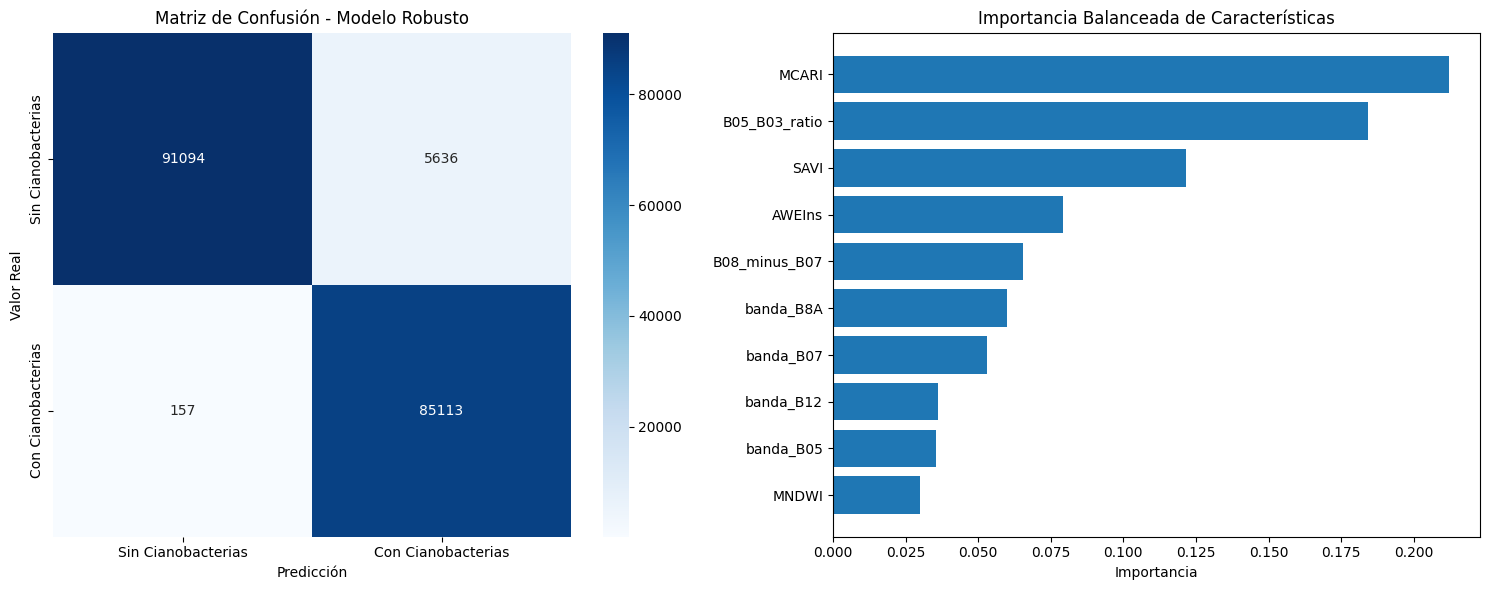


=== PIPELINE COMPLETADO EXITOSAMENTE ===
Datos extraídos: 910,000 píxeles
Modelo entrenado con 15 características

El modelo está listo para hacer predicciones en nuevas imágenes!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------- Selección de características -----------------------------
def seleccionar_caracteristicas_robustas(df, k_best=15):
    """
    Selecciona las características más robustas y menos colineales
    """
    print("🔍 SELECCIONANDO CARACTERÍSTICAS ROBUSTAS...")
    
    # Características a evitar por ser muy específicas
    caracteristicas_especificas = [
        'FAI', 'B07_B03_ratio', 'B07_minus_B04', 'CHL_RedEdge', 
        'B05_minus_B04', 'B8A_B05_ratio', 'B07_B05_ratio'
    ]
    
    # Seleccionar columnas de interés
    feature_cols = [col for col in df.columns if col not in ['fecha', 'imagen', 'row', 'col', 'etiqueta']]
    feature_cols_filtradas = [col for col in feature_cols if col not in caracteristicas_especificas]
    
    print(f"   📊 Características originales: {len(feature_cols)}")
    print(f"   🚫 Características específicas removidas: {len(caracteristicas_especificas)}")
    print(f"   ✅ Características restantes: {len(feature_cols_filtradas)}")
    
    return feature_cols_filtradas

# ----------------------------- Entrenamiento del modelo -----------------------------
def entrenar_modelo_robusto(df, test_size=0.2, n_estimators=200, max_depth=10):
    """
    Entrena un modelo más robusto con regularización y características seleccionadas
    """
    print("\n=== ENTRENAMIENTO DEL MODELO ROBUSTO ===")
    
    # 1. Seleccionar características robustas
    feature_cols = seleccionar_caracteristicas_robustas(df)
    
    # 2. Preparar datos
    X = df[feature_cols].copy()
    y = df['etiqueta'].copy()
    
    # 3. Limpiar datos
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    
    # 4. Normalizar características
    print("🔧 Normalizando características...")
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    # 5. Selección adicional por importancia estadística
    print("📈 Seleccionando características por importancia estadística...")
    selector = SelectKBest(score_func=f_classif, k=min(15, len(feature_cols)))
    X_selected = selector.fit_transform(X_scaled, y)
    selected_features = X_scaled.columns[selector.get_support()]
    
    print(f"   ✅ Características finales seleccionadas: {len(selected_features)}")
    print(f"   📋 Características: {list(selected_features)}")
    
    # 6. División de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # 7. Modelo Random Forest robusto
    print("🤖 Entrenando Random Forest con regularización...")
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    
    # 8. Validación cruzada
    print("🔄 Evaluando con validación cruzada...")
    cv_scores = cross_val_score(rf_model, X_selected, y, cv=5, scoring='f1_macro')
    print(f"   📊 F1-Score CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    # 9. Predicciones en test
    y_pred = rf_model.predict(X_test)
    
    # 10. Reporte
    print("\n=== RESULTADOS DEL MODELO ROBUSTO ===")
    print("📋 Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['Sin Cianobacterias', 'Con Cianobacterias']))
    
    # 11. Importancia de características
    feature_importance = pd.DataFrame({
        'caracteristica': selected_features,
        'importancia': rf_model.feature_importances_
    }).sort_values('importancia', ascending=False)
    
    print(f"\n📊 Top 10 características más importantes:")
    print(feature_importance.head(10))
    
    importancia_max = feature_importance.iloc[0]['importancia']
    if importancia_max < 0.15:
        print("✅ Importancia bien distribuida - Mejor generalización")
    else:
        print(f"⚠️  Característica dominante ({importancia_max:.1%}) - Posible sobreajuste")
    
    # 12. Visualizaciones
    crear_visualizaciones_robustas(y_test, y_pred, feature_importance)
    
    return rf_model, selected_features, feature_importance, scaler

# ----------------------------- Visualizaciones -----------------------------
def crear_visualizaciones_robustas(y_test, y_pred, feature_importance):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Sin Cianobacterias', 'Con Cianobacterias'],
                yticklabels=['Sin Cianobacterias', 'Con Cianobacterias'])
    axes[0].set_title('Matriz de Confusión - Modelo Robusto')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')
    
    # Importancia de características
    top_features = feature_importance.head(10)
    axes[1].barh(range(len(top_features)), top_features['importancia'])
    axes[1].set_yticks(range(len(top_features)))
    axes[1].set_yticklabels(top_features['caracteristica'])
    axes[1].set_xlabel('Importancia')
    axes[1].set_title('Importancia Balanceada de Características')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# ----------------------------- Evaluación temporal -----------------------------
def evaluar_robustez_temporal(df, modelo, caracteristicas, scaler):
    """
    Evalúa si el modelo generaliza bien a través del tiempo
    """
    print("\n🕐 EVALUANDO ROBUSTEZ TEMPORAL...")
    
    fechas_unicas = df['fecha'].unique()
    if len(fechas_unicas) < 4:
        print("⚠️  Pocas fechas para evaluación temporal")
        return
    
    fechas_train = fechas_unicas[:len(fechas_unicas)//2]
    fechas_test = fechas_unicas[len(fechas_unicas)//2:]
    
    train_temporal = df[df['fecha'].isin(fechas_train)]
    test_temporal = df[df['fecha'].isin(fechas_test)]
    
    if len(test_temporal) < 100:
        print("⚠️  Muy pocos datos para test temporal")
        return
    
    # Preparar datos
    X_train_temp = train_temporal[caracteristicas].replace([np.inf, -np.inf], np.nan).fillna(train_temporal[caracteristicas].median())
    X_test_temp = test_temporal[caracteristicas].replace([np.inf, -np.inf], np.nan).fillna(test_temporal[caracteristicas].median())
    
    # Transformar con scaler
    X_train_temp_scaled = scaler.transform(X_train_temp)
    X_test_temp_scaled = scaler.transform(X_test_temp)
    
    y_train_temp = train_temporal['etiqueta']
    y_test_temp = test_temporal['etiqueta']
    
    # Entrenar y probar
    modelo.fit(X_train_temp_scaled, y_train_temp)
    y_pred_temp = modelo.predict(X_test_temp_scaled)
    
    print(f"   📅 Fechas entrenamiento: {len(fechas_train)} ({fechas_train[0]} a {fechas_train[-1]})")
    print(f"   📅 Fechas prueba: {len(fechas_test)} ({fechas_test[0]} a {fechas_test[-1]})")
    
    accuracy_temp = accuracy_score(y_test_temp, y_pred_temp)
    f1_temp = f1_score(y_test_temp, y_pred_temp, average='macro')
    
    print(f"      Accuracy: {accuracy_temp:.3f}")
    print(f"      F1-Score: {f1_temp:.3f}")
    
    if f1_temp > 0.7:
        print("✅ Buena generalización temporal")
    elif f1_temp > 0.5:
        print("⚠️  Generalización temporal moderada")
    else:
        print("❌ Pobre generalización temporal")

# ----------------------------- Pipeline completo -----------------------------
def pipeline_robusto(DATA_DIR):
    print("=== PIPELINE ROBUSTO DE DETECCIÓN DE CIANOBACTERIAS ===")
    
    csv_path = Path(DATA_DIR).parent / "datos_cianobacterias.csv"
    if not csv_path.exists():
        print("❌ Primero ejecuta el pipeline de extracción de datos")
        return None
    
    df = pd.read_csv(csv_path)
    print(f"📊 Datos cargados: {len(df):,} píxeles")
    
    # Entrenar modelo robusto
    modelo, caracteristicas, importancia, scaler = entrenar_modelo_robusto(df)
    
    # # Evaluar robustez temporal
    # evaluar_robustez_temporal(df, modelo, caracteristicas, scaler)
    
    return df, modelo, caracteristicas, importancia, scaler


if __name__ == "__main__":
    DATA_DIR = "./data/GIS/Atitlan"
    
    datos, modelo, caracteristicas, importancia, scaler = pipeline_robusto(DATA_DIR)
    
    if datos is not None:
        print(f"\n=== PIPELINE COMPLETADO EXITOSAMENTE ===")
        print(f"Datos extraídos: {len(datos):,} píxeles")
        print(f"Modelo entrenado con {len(caracteristicas)} características")
        print("\nEl modelo está listo para hacer predicciones en nuevas imágenes!")
    else:
        print("ERROR: El pipeline falló")


=== PIPELINE ROBUSTO DE DETECCIÓN DE CIANOBACTERIAS ===
📊 Datos cargados: 910,000 píxeles

=== ENTRENAMIENTO DEL MODELO ROBUSTO ===
🔍 SELECCIONANDO CARACTERÍSTICAS ROBUSTAS...
   📊 Características originales: 37
   🚫 Características específicas removidas: 7
   ✅ Características restantes: 30
🔧 Normalizando características...
📈 Seleccionando características por importancia estadística...
   ✅ Características finales seleccionadas: 15
   📋 Características: ['banda_B02', 'banda_B03', 'banda_B04', 'banda_B05', 'banda_B07', 'banda_B08', 'banda_B8A', 'banda_B11', 'banda_B12', 'SAVI', 'MNDWI', 'AWEIns', 'MCARI', 'B05_B03_ratio', 'B08_minus_B07']
🤖 Entrenando Random Forest con regularización...
🔄 Evaluando con validación cruzada...
   📊 F1-Score CV: 0.965 ± 0.016

=== RESULTADOS DEL MODELO ROBUSTO ===
📋 Reporte de clasificación:
                    precision    recall  f1-score   support

Sin Cianobacterias       1.00      0.94      0.97     96730
Con Cianobacterias       0.94      1.00      0

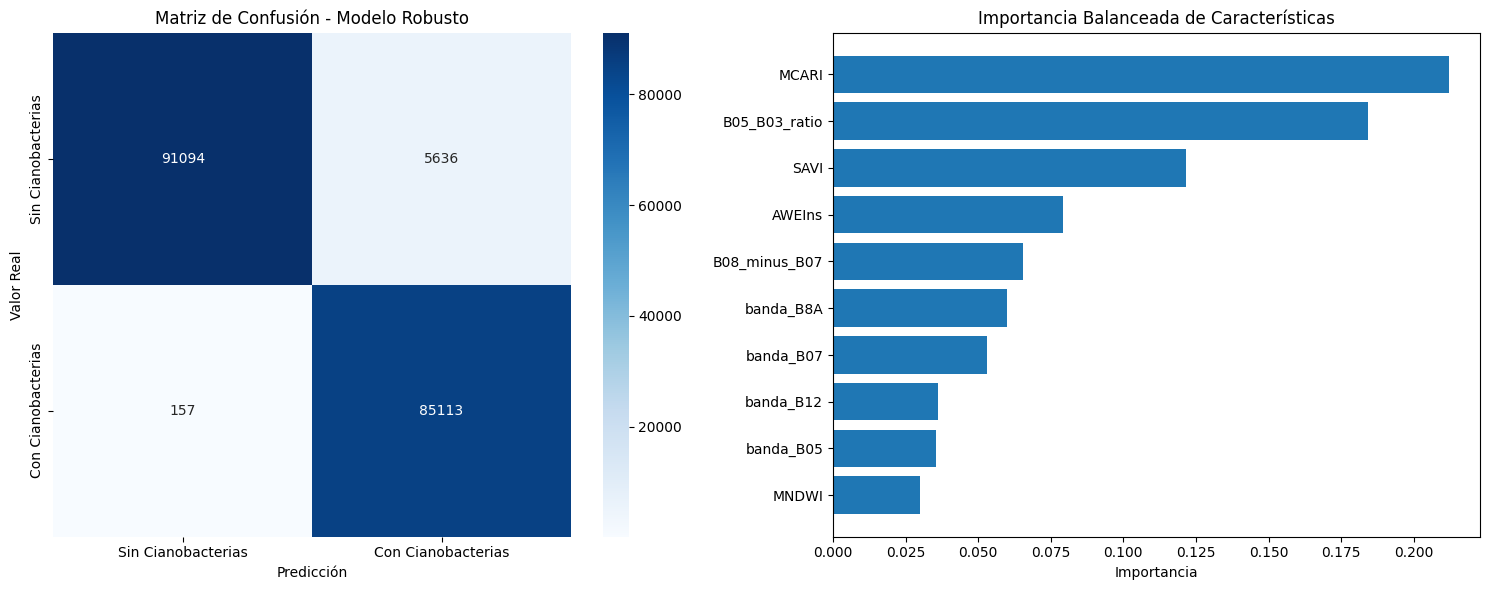


=== PIPELINE COMPLETADO EXITOSAMENTE ===
Datos extraídos: 910,000 píxeles
Modelo entrenado con 15 características

El modelo está listo para hacer predicciones en nuevas imágenes!


In [10]:
DATA_DIR_AMA = "./data/GIS/Amatitlan"
datos_amatitlan, modelo_amatitlan, caracteristicas_amatitlan, importancia_amatitlan, scaler_amatitlan = pipeline_robusto(DATA_DIR_AMA)
if datos_amatitlan is not None:
  print(f"\n=== PIPELINE COMPLETADO EXITOSAMENTE ===")
  print(f"Datos extraídos: {len(datos_amatitlan):,} píxeles")
  print(f"Modelo entrenado con {len(caracteristicas_amatitlan)} características")
  print("\nEl modelo está listo para hacer predicciones en nuevas imágenes!")
else:
  print("ERROR: El pipeline falló")

Lo que podemos ver de los modelos es que en promedio tienen un 97% de acurrancy para los 2 lagos, demostrando que son muy buenos para predecir si el pixel sera o no cianobacteria. De entre todos los modelos este ha sido el mejor que se ha hecho

## Parte 12

Ahora haremos un modelo hibrido, en este caso es usar lo que nos predijo la serie que hicimos al inicio .



In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

def crear_serie_temporal_ndci(ndci_data):
    """
    Crea un DataFrame con la serie temporal promedio de NDCI por fecha.
    """
    print(f"\n=== CREANDO SERIE TEMPORAL PARA NDCI ===")
    fechas, valores_promedio = [], []

    for fecha, array in sorted(ndci_data.items()):
        if array is not None and np.any(~np.isnan(array)):
            media = np.nanmean(array)
            fechas.append(pd.to_datetime(fecha))
            valores_promedio.append(media)
            print(f"  {fecha}: {media:.3f}")

    df_series = pd.DataFrame({'fecha': fechas, 'NDCI_mean': valores_promedio})
    df_series = df_series.sort_values('fecha').reset_index(drop=True)
    return df_series

def preparar_features(df_series):
    """
    Agrega características temporales y lags para mejorar la predicción.
    """
    df = df_series.copy()
    df['dias'] = (df['fecha'] - df['fecha'].min()).dt.days
    df['mes'] = df['fecha'].dt.month
    df['dia_del_ano'] = df['fecha'].dt.dayofyear
    # Lags de NDCI
    df['ndci_lag1'] = df['NDCI_mean'].shift(1).fillna(method='bfill')
    df['ndci_lag2'] = df['NDCI_mean'].shift(2).fillna(method='bfill')
    df['ndci_lag3'] = df['NDCI_mean'].shift(3).fillna(method='bfill')
    
    X = df[['dias', 'mes', 'dia_del_ano', 'ndci_lag1', 'ndci_lag2', 'ndci_lag3']]
    y = df['NDCI_mean']
    
    return X, y

def entrenar_modelo_ndci(df_series):
    print(f"\n=== ENTRENANDO MODELO DE PREDICCIÓN PARA NDCI ===")
    X, y = preparar_features(df_series)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"R2 en test: {r2:.3f}, MAE en test: {mae:.3f}")
    
    return model, df_series

def predecir_ndci(model, df_series, dias_futuros=30):
    """
    Predice NDCI para los próximos 'dias_futuros' días usando las features anteriores.
    """
    last_date = df_series['fecha'].max()
    fechas_pred = pd.date_range(last_date + pd.Timedelta(days=1), periods=dias_futuros)

    df_temp = df_series.copy()
    preds = []

    for fecha in fechas_pred:
        dias = (fecha - df_series['fecha'].min()).days
        mes = fecha.month
        dia_del_ano = fecha.timetuple().tm_yday
        # Usamos los últimos lags disponibles
        ndci_lag1 = df_temp['NDCI_mean'].iloc[-1]
        ndci_lag2 = df_temp['NDCI_mean'].iloc[-2] if len(df_temp) > 1 else ndci_lag1
        ndci_lag3 = df_temp['NDCI_mean'].iloc[-3] if len(df_temp) > 2 else ndci_lag2
        
        X_pred = np.array([[dias, mes, dia_del_ano, ndci_lag1, ndci_lag2, ndci_lag3]])
        y_pred = model.predict(X_pred)[0]
        preds.append(y_pred)
        
        # Añadimos la predicción como "último NDCI" para los próximos lags
        df_temp = pd.concat([df_temp, pd.DataFrame({'fecha':[fecha], 'NDCI_mean':[y_pred]})], ignore_index=True)

    df_pred = pd.DataFrame({'fecha': fechas_pred, 'NDCI_pred': preds})
    return df_pred

def plot_serie_temporal_ndci(df_series, df_pred=None):
    plt.figure(figsize=(12,6))
    plt.plot(df_series['fecha'], df_series['NDCI_mean'], 'o-', label='NDCI observado')

    if df_pred is not None:
        plt.plot(df_pred['fecha'], df_pred['NDCI_pred'], 's--', label='NDCI predicho', color='red')

    plt.xlabel('Fecha')
    plt.ylabel('NDCI')
    plt.title('Serie temporal de NDCI')
    plt.legend()
    plt.grid(True)
    plt.show()


### Atitlan

C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag1'] = df['NDCI_mean'].shift(1).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag2'] = df['NDCI_mean'].shift(2).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag3'] = df['NDCI_mean'].shift(3).fillna(method='bfill')


R2 en test: -0.048, MAE en test: 0.080


e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science

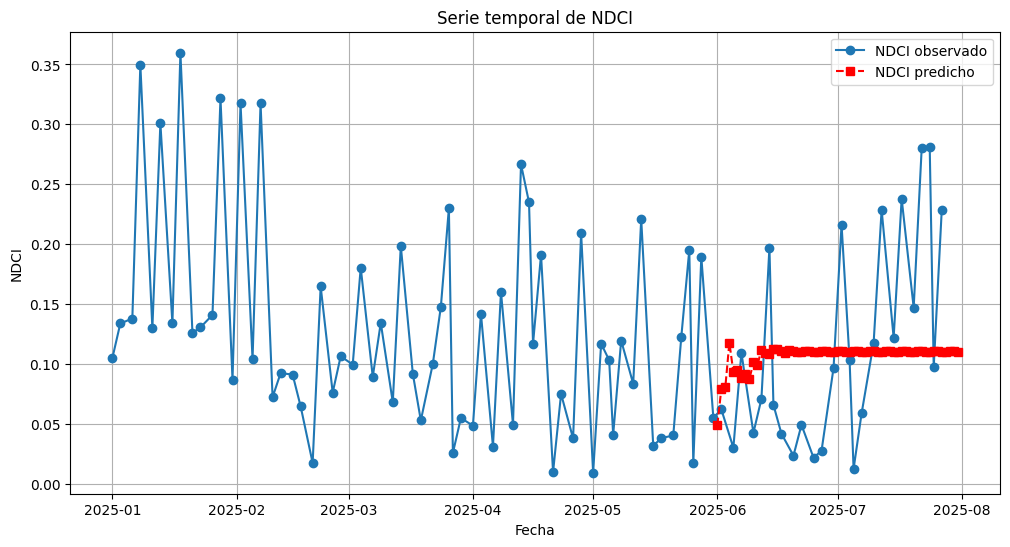

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------------
# Crear serie temporal promedio de NDCI
# -----------------------------
def crear_serie_temporal_ndci(ndci_data):
    """
    Crea un DataFrame con la serie temporal promedio de NDCI por fecha.
    ndci_data: diccionario {fecha: array_ndci}
    """
    fechas, valores_promedio = [], []

    for fecha, array in sorted(ndci_data.items()):
        if array is not None and np.any(~np.isnan(array)):
            media = np.nanmean(array)
            fechas.append(pd.to_datetime(fecha))
            valores_promedio.append(media)

    df_series = pd.DataFrame({'fecha': fechas, 'NDCI_mean': valores_promedio})
    df_series = df_series.sort_values('fecha').reset_index(drop=True)
    return df_series

# -----------------------------
# Preparar features con lags y variables temporales
# -----------------------------
def preparar_features(df_series):
    df = df_series.copy()
    df['dias'] = (df['fecha'] - df['fecha'].min()).dt.days
    df['mes'] = df['fecha'].dt.month
    df['dia_del_ano'] = df['fecha'].dt.dayofyear
    df['ndci_lag1'] = df['NDCI_mean'].shift(1).fillna(method='bfill')
    df['ndci_lag2'] = df['NDCI_mean'].shift(2).fillna(method='bfill')
    df['ndci_lag3'] = df['NDCI_mean'].shift(3).fillna(method='bfill')

    X = df[['dias', 'mes', 'dia_del_ano', 'ndci_lag1', 'ndci_lag2', 'ndci_lag3']]
    y = df['NDCI_mean']
    return X, y

# -----------------------------
# Entrenar modelo Random Forest
# -----------------------------
def entrenar_modelo_ndci(df_series):
    X, y = preparar_features(df_series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"R2 en test: {r2_score(y_test, y_pred):.3f}, MAE en test: {mean_absolute_error(y_test, y_pred):.3f}")
    return model, df_series

# -----------------------------
# Predecir para un rango de fechas
# -----------------------------
def predecir_ndci_rango(model, df_series, fechas_pred):
    df_temp = df_series.copy()
    preds = []

    for fecha in fechas_pred:
        dias = (fecha - df_series['fecha'].min()).days
        mes = fecha.month
        dia_del_ano = fecha.timetuple().tm_yday
        ndci_lag1 = df_temp['NDCI_mean'].iloc[-1]
        ndci_lag2 = df_temp['NDCI_mean'].iloc[-2] if len(df_temp) > 1 else ndci_lag1
        ndci_lag3 = df_temp['NDCI_mean'].iloc[-3] if len(df_temp) > 2 else ndci_lag2

        X_pred = [[dias, mes, dia_del_ano, ndci_lag1, ndci_lag2, ndci_lag3]]
        y_pred = model.predict(X_pred)[0]
        preds.append(y_pred)

        df_temp = pd.concat([df_temp, pd.DataFrame({'fecha':[fecha], 'NDCI_mean':[y_pred]})], ignore_index=True)

    df_pred = pd.DataFrame({'fecha': fechas_pred, 'NDCI_pred': preds})
    return df_pred

# -----------------------------
# Graficar serie temporal
# -----------------------------
def plot_serie_temporal_ndci(df_series, df_pred=None):
    plt.figure(figsize=(12,6))
    plt.plot(df_series['fecha'], df_series['NDCI_mean'], 'o-', label='NDCI observado')
    if df_pred is not None:
        plt.plot(df_pred['fecha'], df_pred['NDCI_pred'], 's--', label='NDCI predicho', color='red')
    plt.xlabel('Fecha')
    plt.ylabel('NDCI')
    plt.title('Serie temporal de NDCI')
    plt.legend()
    plt.grid(True)
    plt.show()


df_series_atl = crear_serie_temporal_ndci(atitlan_ndci)


model_atl, df_series_atl = entrenar_modelo_ndci(df_series_atl)


fechas_pred = pd.date_range("2025-06-01", "2025-07-31")

df_pred_jun_jul = predecir_ndci_rango(model_atl, df_series_atl, fechas_pred)

plot_serie_temporal_ndci(df_series_atl, df_pred_jun_jul)


Obtenemos las temperaturas

In [33]:
import pandas as pd

# Leer CSV
temp_df = pd.read_csv("temperaturas_lagos_ene_jul_2025.csv")

temp_df['time'] = pd.to_datetime(temp_df['time'])

# Filtrar solo Amatitlán
temp_amati = temp_df[temp_df['Lago'] == 'Atitlan'].copy()

temp_amati.reset_index(drop=True, inplace=True)

# Revisar
print(temp_amati.head())


        time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0 2025-01-01                22.1                13.8                 17.2   
1 2025-01-02                22.7                14.2                 17.4   
2 2025-01-03                22.9                15.6                 18.4   
3 2025-01-04                23.1                16.2                 18.4   
4 2025-01-05                22.1                13.9                 17.5   

      Lago  
0  Atitlan  
1  Atitlan  
2  Atitlan  
3  Atitlan  
4  Atitlan  


In [34]:
df_fusion = pd.merge(df_pred_jun_jul, temp_amati,
                     left_on='fecha', right_on='time', how='left')

# Eliminamos columnas duplicadas si lo deseas
df_fusion.drop(columns=['time', 'Lago'], inplace=True)

# Revisamos el resultado
print(df_fusion.head())

       fecha  NDCI_pred  temperature_2m_max  temperature_2m_min  \
0 2025-06-01   0.048776                24.1                16.4   
1 2025-06-02   0.079504                22.3                16.9   
2 2025-06-03   0.081091                22.0                17.2   
3 2025-06-04   0.117949                22.2                17.5   
4 2025-06-05   0.093236                21.2                18.1   

   temperature_2m_mean  
0                 19.4  
1                 19.0  
2                 19.1  
3                 18.9  
4                 19.0  


Ahora seleccionamos las selected features del modelo anterior

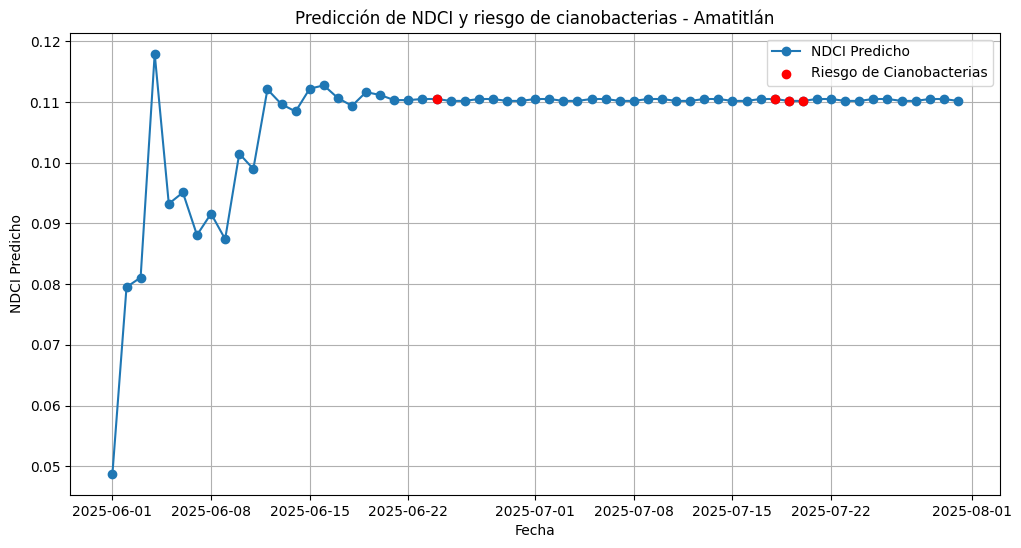

        fecha  NDCI_pred  temperature_2m_mean  Contaminacion_pred
0  2025-06-01   0.048776                 19.4                   0
1  2025-06-02   0.079504                 19.0                   0
2  2025-06-03   0.081091                 19.1                   0
3  2025-06-04   0.117949                 18.9                   0
4  2025-06-05   0.093236                 19.0                   0
..        ...        ...                  ...                 ...
56 2025-07-27   0.110179                 19.7                   0
57 2025-07-28   0.110179                 19.8                   0
58 2025-07-29   0.110492                 19.0                   0
59 2025-07-30   0.110492                 19.0                   0
60 2025-07-31   0.110179                 19.4                   0

[61 rows x 4 columns]


In [36]:
import pandas as pd
import matplotlib.pyplot as plt


UMBRAL_NDCI = 0.05         
UMBRAL_TEMP_MEDIA = 20.0  


df_fusion['Contaminacion_pred'] = ((df_fusion['NDCI_pred'] > UMBRAL_NDCI) & 
                                   (df_fusion['temperature_2m_mean'] > UMBRAL_TEMP_MEDIA)).astype(int)


plt.figure(figsize=(12,6))
plt.plot(df_fusion['fecha'], df_fusion['NDCI_pred'], label='NDCI Predicho', marker='o')

# Resaltar los días con riesgo
dias_riesgo = df_fusion[df_fusion['Contaminacion_pred'] == 1]
plt.scatter(dias_riesgo['fecha'], dias_riesgo['NDCI_pred'], color='red', label='Riesgo de Cianobacterias', zorder=5)

plt.xlabel('Fecha')
plt.ylabel('NDCI Predicho')
plt.title('Predicción de NDCI y riesgo de cianobacterias - Amatitlán')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Revisar resultados
# -----------------------------
print(df_fusion[['fecha', 'NDCI_pred', 'temperature_2m_mean', 'Contaminacion_pred']])


Ahora procedemos a la clasificacion

=== Clasificación ===
                    precision    recall  f1-score   support

Sin cianobacterias       0.85      1.00      0.92        11
Con cianobacterias       0.00      0.00      0.00         2

          accuracy                           0.85        13
         macro avg       0.42      0.50      0.46        13
      weighted avg       0.72      0.85      0.78        13

Accuracy: 0.8461538461538461

Matriz de confusión:
 [[11  0]
 [ 2  0]]


e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


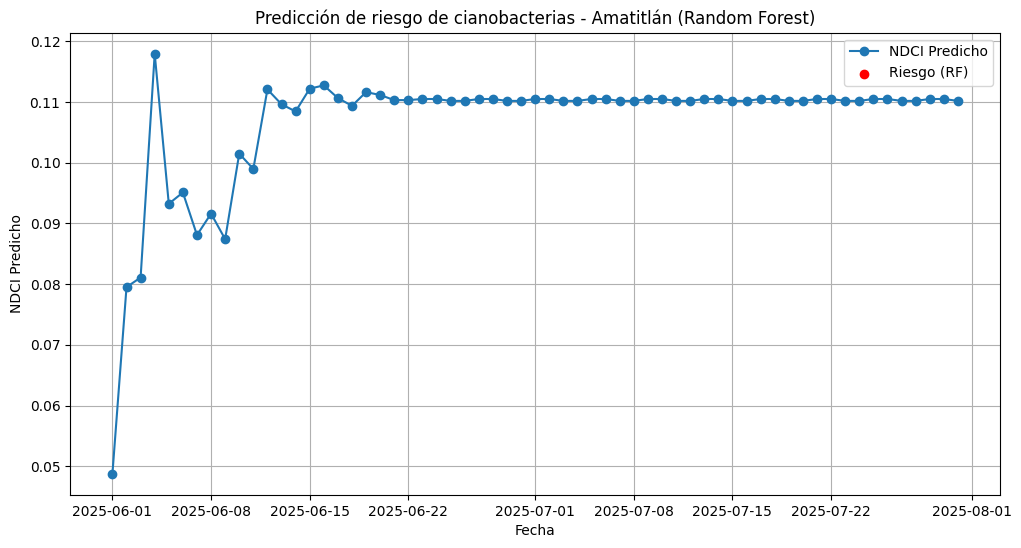

In [38]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


features = ['NDCI_pred', 'temperature_2m_mean']
X = df_fusion[features]
y = df_fusion['Contaminacion_pred']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # shuffle=False si queremos mantener orden temporal
)


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

print("=== Clasificación ===")
print(classification_report(y_test, y_pred, target_names=['Sin cianobacterias', 'Con cianobacterias']))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_fusion['fecha'], df_fusion['NDCI_pred'], label='NDCI Predicho', marker='o')

dias_riesgo_model = df_fusion.iloc[y_test.index][y_pred == 1]
plt.scatter(dias_riesgo_model['fecha'], dias_riesgo_model['NDCI_pred'], color='red', label='Riesgo (RF)', zorder=5)

plt.xlabel('Fecha')
plt.ylabel('NDCI Predicho')
plt.title('Predicción de riesgo de cianobacterias - Amatitlán (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()


### Amatitlan

Con amatitlan es lo mismo

C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag1'] = df['NDCI_mean'].shift(1).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag2'] = df['NDCI_mean'].shift(2).fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_4976\3468833409.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ndci_lag3'] = df['NDCI_mean'].shift(3).fillna(method='bfill')


R2 en test: 0.032, MAE en test: 0.091


e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\Data_Science

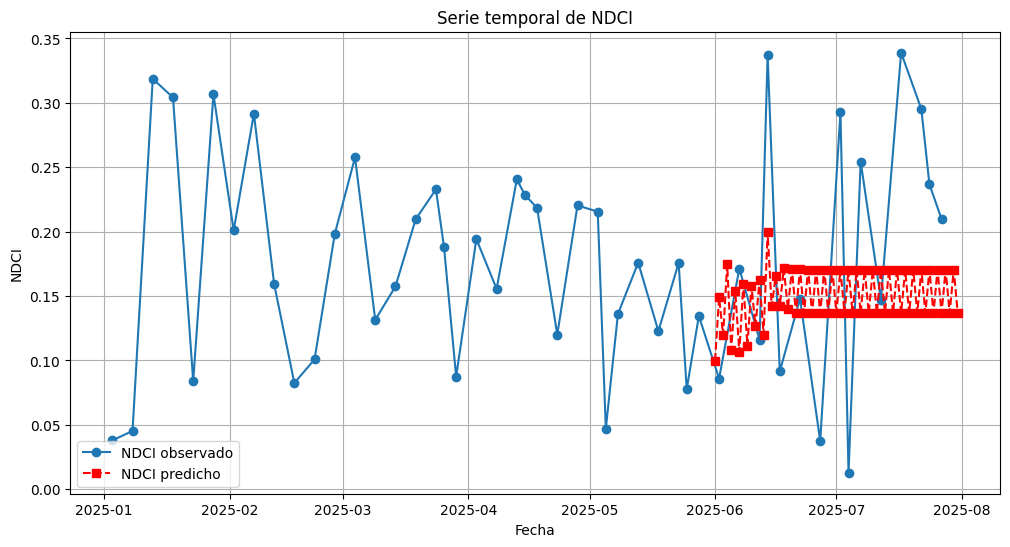

In [42]:
df_series_amtl = crear_serie_temporal_ndci(amatitlan_ndci)


model_aml, df_series_aml = entrenar_modelo_ndci(df_series_amtl)


fechas_pred = pd.date_range("2025-06-01", "2025-07-31")

df_pred_jun_jul_aml = predecir_ndci_rango(model_aml, df_series_aml, fechas_pred)

plot_serie_temporal_ndci(df_series_amtl, df_pred_jun_jul_aml)

In [43]:
import pandas as pd

# Leer CSV
temp_df = pd.read_csv("temperaturas_lagos_ene_jul_2025.csv")

temp_df['time'] = pd.to_datetime(temp_df['time'])

# Filtrar solo Amatitlán
temp_ama = temp_df[temp_df['Lago'] == 'Amatitlan'].copy()

temp_ama.reset_index(drop=True, inplace=True)

# Revisar
print(temp_ama.head())


        time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0 2025-01-01                26.0                15.6                 20.0   
1 2025-01-02                23.4                16.6                 19.3   
2 2025-01-03                23.9                16.3                 18.9   
3 2025-01-04                23.7                15.6                 18.6   
4 2025-01-05                27.6                14.2                 19.4   

        Lago  
0  Amatitlan  
1  Amatitlan  
2  Amatitlan  
3  Amatitlan  
4  Amatitlan  


In [44]:
df_fusion_aml = pd.merge(df_pred_jun_jul_aml, temp_ama,
                     left_on='fecha', right_on='time', how='left')


df_fusion_aml.drop(columns=['time', 'Lago'], inplace=True)

# Revisamos el resultado
print(df_fusion_aml.head())

       fecha  NDCI_pred  temperature_2m_max  temperature_2m_min  \
0 2025-06-01   0.099831                29.3                17.0   
1 2025-06-02   0.148991                28.2                17.8   
2 2025-06-03   0.119690                25.5                17.4   
3 2025-06-04   0.174586                25.0                18.4   
4 2025-06-05   0.108362                25.7                18.3   

   temperature_2m_mean  
0                 21.5  
1                 21.0  
2                 20.5  
3                 20.3  
4                 21.2  


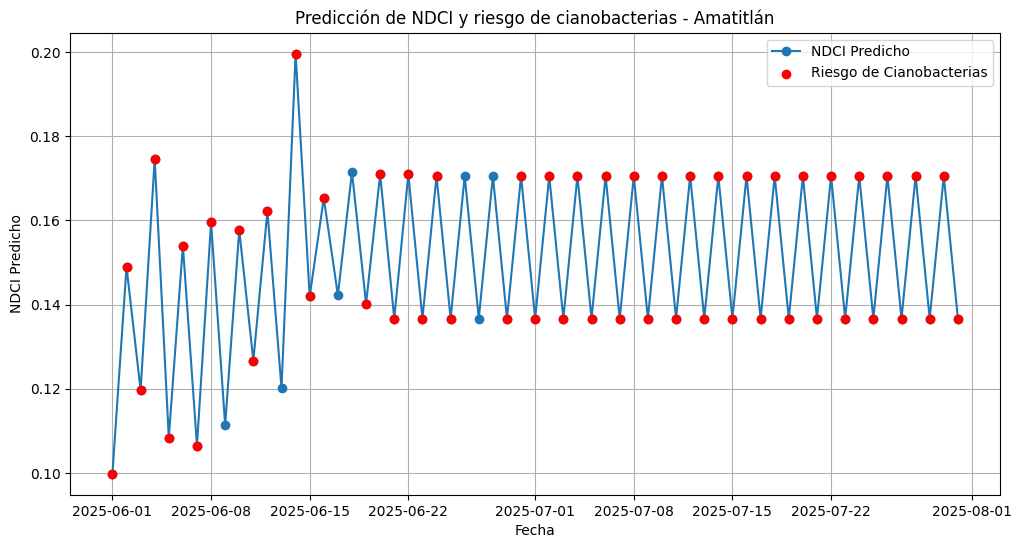

        fecha  NDCI_pred  temperature_2m_mean  Contaminacion_pred
0  2025-06-01   0.099831                 21.5                   1
1  2025-06-02   0.148991                 21.0                   1
2  2025-06-03   0.119690                 20.5                   1
3  2025-06-04   0.174586                 20.3                   1
4  2025-06-05   0.108362                 21.2                   1
..        ...        ...                  ...                 ...
56 2025-07-27   0.136696                 21.2                   1
57 2025-07-28   0.170559                 22.1                   1
58 2025-07-29   0.136696                 21.0                   1
59 2025-07-30   0.170559                 21.1                   1
60 2025-07-31   0.136696                 21.1                   1

[61 rows x 4 columns]


In [45]:
import pandas as pd
import matplotlib.pyplot as plt


UMBRAL_NDCI = 0.05         
UMBRAL_TEMP_MEDIA = 20.0  


df_fusion_aml['Contaminacion_pred'] = ((df_fusion_aml['NDCI_pred'] > UMBRAL_NDCI) & 
                                   (df_fusion_aml['temperature_2m_mean'] > UMBRAL_TEMP_MEDIA)).astype(int)


plt.figure(figsize=(12,6))
plt.plot(df_fusion_aml['fecha'], df_fusion_aml['NDCI_pred'], label='NDCI Predicho', marker='o')

# Resaltar los días con riesgo
dias_riesgo = df_fusion_aml[df_fusion_aml['Contaminacion_pred'] == 1]
plt.scatter(dias_riesgo['fecha'], dias_riesgo['NDCI_pred'], color='red', label='Riesgo de Cianobacterias', zorder=5)

plt.xlabel('Fecha')
plt.ylabel('NDCI Predicho')
plt.title('Predicción de NDCI y riesgo de cianobacterias - Amatitlán')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Revisar resultados
# -----------------------------
print(df_fusion_aml[['fecha', 'NDCI_pred', 'temperature_2m_mean', 'Contaminacion_pred']])


=== Clasificación Amatitlan ===
                    precision    recall  f1-score   support

Sin cianobacterias       0.00      0.00      0.00       0.0
Con cianobacterias       0.00      0.00      0.00      13.0

          accuracy                           0.00      13.0
         macro avg       0.00      0.00      0.00      13.0
      weighted avg       0.00      0.00      0.00      13.0

Accuracy: 1.0

Matriz de confusión:
 [[ 0  0]
 [13  0]]


e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Data_Science\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Data_Science\.venv\Lib\site-packages\sklea

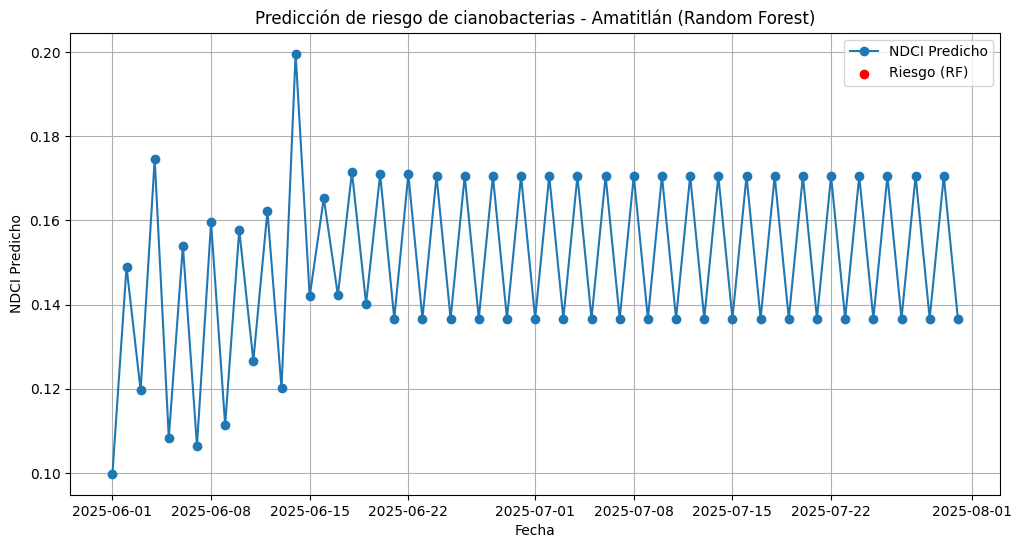

In [47]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


features = ['NDCI_pred', 'temperature_2m_mean']
X = df_fusion_aml[features]
y = df_fusion_aml['Contaminacion_pred']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # shuffle=False si queremos mantener orden temporal
)


rf_model_aml = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
rf_model_aml.fit(X_train, y_train)


y_pred_aml = rf_model_aml.predict(X_test)

print("=== Clasificación Amatitlan ===")
print(classification_report(y_test, y_pred, target_names=['Sin cianobacterias', 'Con cianobacterias']))
print("Accuracy:", accuracy_score(y_test, y_pred_aml))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_fusion_aml['fecha'], df_fusion_aml['NDCI_pred'], label='NDCI Predicho', marker='o')

dias_riesgo_model = df_fusion_aml.iloc[y_test.index][y_pred == 1]
plt.scatter(dias_riesgo_model['fecha'], dias_riesgo_model['NDCI_pred'], color='red', label='Riesgo (RF)', zorder=5)

plt.xlabel('Fecha')
plt.ylabel('NDCI Predicho')
plt.title('Predicción de riesgo de cianobacterias - Amatitlán (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()


Podemos ver que el modelo de amatitlan es bastante malo pero el de atitlan si es muy bueno. Esto se debe al que de amatitlan hizo mucha meozacion y entonces no aprendio nada sino memorizo todos los datos

## Parte 13 

Podemos ver que de los modelos generados el unico con buen desempeño es el random forest, con un accurrancy del 97% para los 2 lagos, en cambio haciendo uso de los demas como el hibrido y la serie no mejoro mucho. 

En el caso de la serie fue bastante mala , no por el RMSE sino por el MAPE que fue  muy alto (153.1%) para el lago de atitlan y un 177.2% para el de amatitlan, 

En el caso del ultimo modelo el acurrancy para el lago de atitlan fue de 87% y para el lago de amatitlan de 100%, lo cual es muy bueno prediciendo el lago de atitlan pero genero memorizacion en el de amatitlan.

Lo muy probable es que para el lago de amatitlan se necesiten mas datos e imagenes para poder predecir  haciendo uso de variable con menos colineealidad con la variable objetivo. Que es loq puede estar provocando esto. 

Lo mismo sucede con la serie, de hecho ese es un problema ya que solo se pudieron trabajar en un rango de 6 meses, cuando lo normal seria en un periodo de 2 o mas años para llegar a predecir 30 dias . Si se puede ver en las graficas de las respectivas series es que al predecir al futuro llegaban a un punto en donde se convertian en una recta. Esto indicaria que el modelo esta proyectando una tendencia, que no sigue los datos que deberia de tener.

El resumen se presenta en la siguiente tabla

| Modelo              | Lago         | Métrica       | Resultado      | Observaciones                                                                 |
|---------------------|-------------|---------------|----------------|--------------------------------------------------------------------------------|
| **Random Forest**   | Atitlán     | Accuracy      | 97%            | Mejor desempeño, logra distinguir bien entre clases.                          |
|                     | Amatitlán   | Accuracy      | 97%            | Igual desempeño, robusto con los datos actuales.                              |
| **Serie Temporal**  | Atitlán     | RMSE          | Bajo           | RMSE aceptable, pero MAPE muy alto (153.1%).                                  |
|                     |             | MAPE          | 153.1%         | Predicción se vuelve recta → falta de datos históricos (solo 6 meses).        |
|                     | Amatitlán   | RMSE          | Bajo           | Igual comportamiento.                                                         |
|                     |             | MAPE          | 177.2%         | Predicción plana → modelo proyecta tendencia sin estacionalidad real.         |
| **Modelo Híbrido**  | Atitlán     | Accuracy      | 87%            | Buen desempeño, aunque menor que RF.                                          |
|                     | Amatitlán   | Accuracy      | 100%           | Probable sobreajuste / memorización debido a colinealidad y pocos datos.      |


## Parte 14

Representaremos los resultados del modelo **Random Forest** directamente sobre un **mapa geoespacial**, lo cual permitirá:

1. **Ubicar zonas de riesgo** de cianobacterias.  
2. **Comparar lagos** (Atitlán y Amatitlán) en un mismo contexto geográfico.  
3. **Dar un valor práctico** a la predicción, mostrando áreas y fechas con posible proliferación.

✅ Rasterio disponible - Soporte completo para TIFF geoespaciales

=== CREANDO VISUALIZACIÓN SIMPLE DE MAPAS ===
🔍 Sin usar modelo ni scaler - Solo mostrando datos existentes
🗺️  CREANDO MAPAS SIMPLES...
📍 Cargando imagen TIFF con información geoespacial...
❌ Error cargando imagen: .data/GIS/Atitlan/openEO_2025-05-23Z.tif: No such file or directory


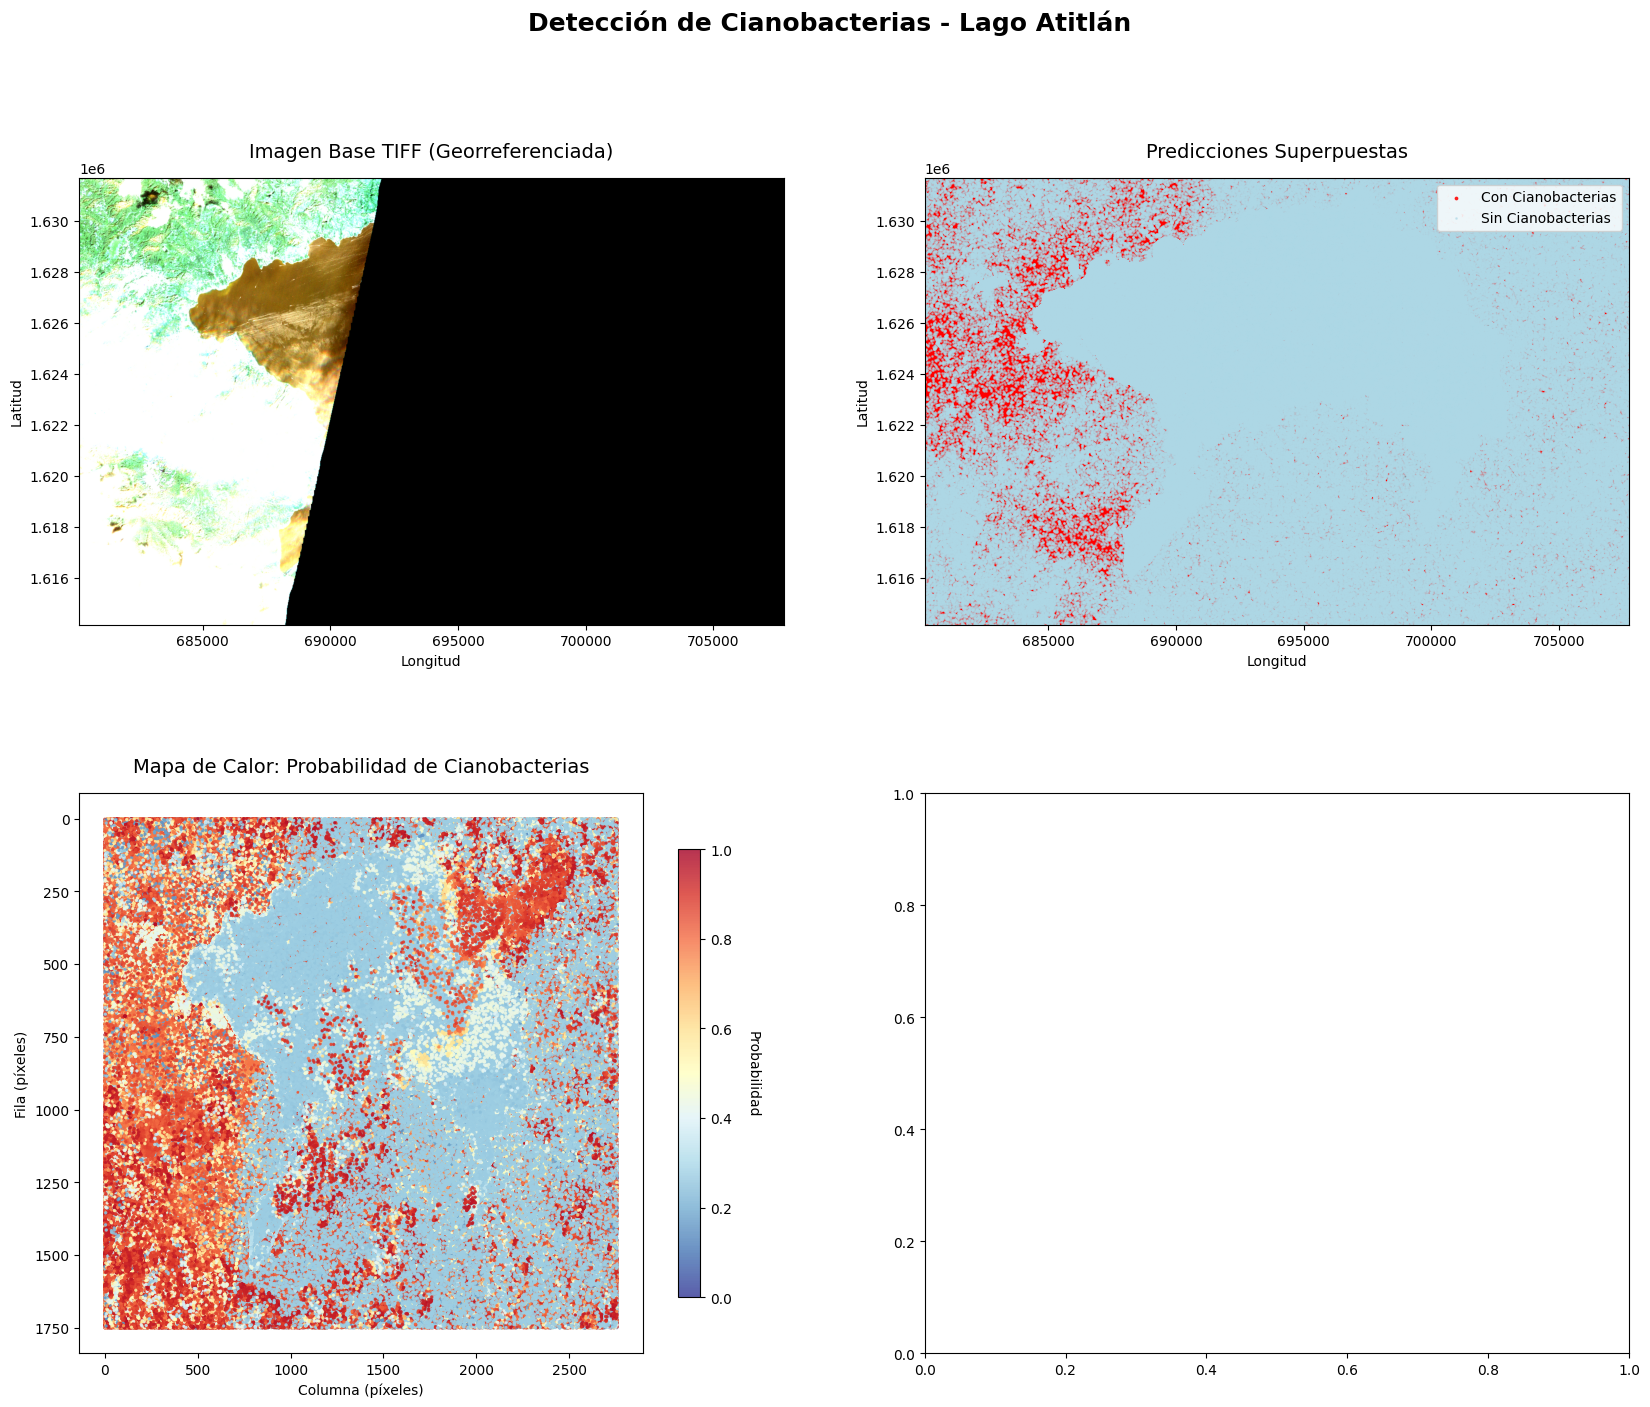

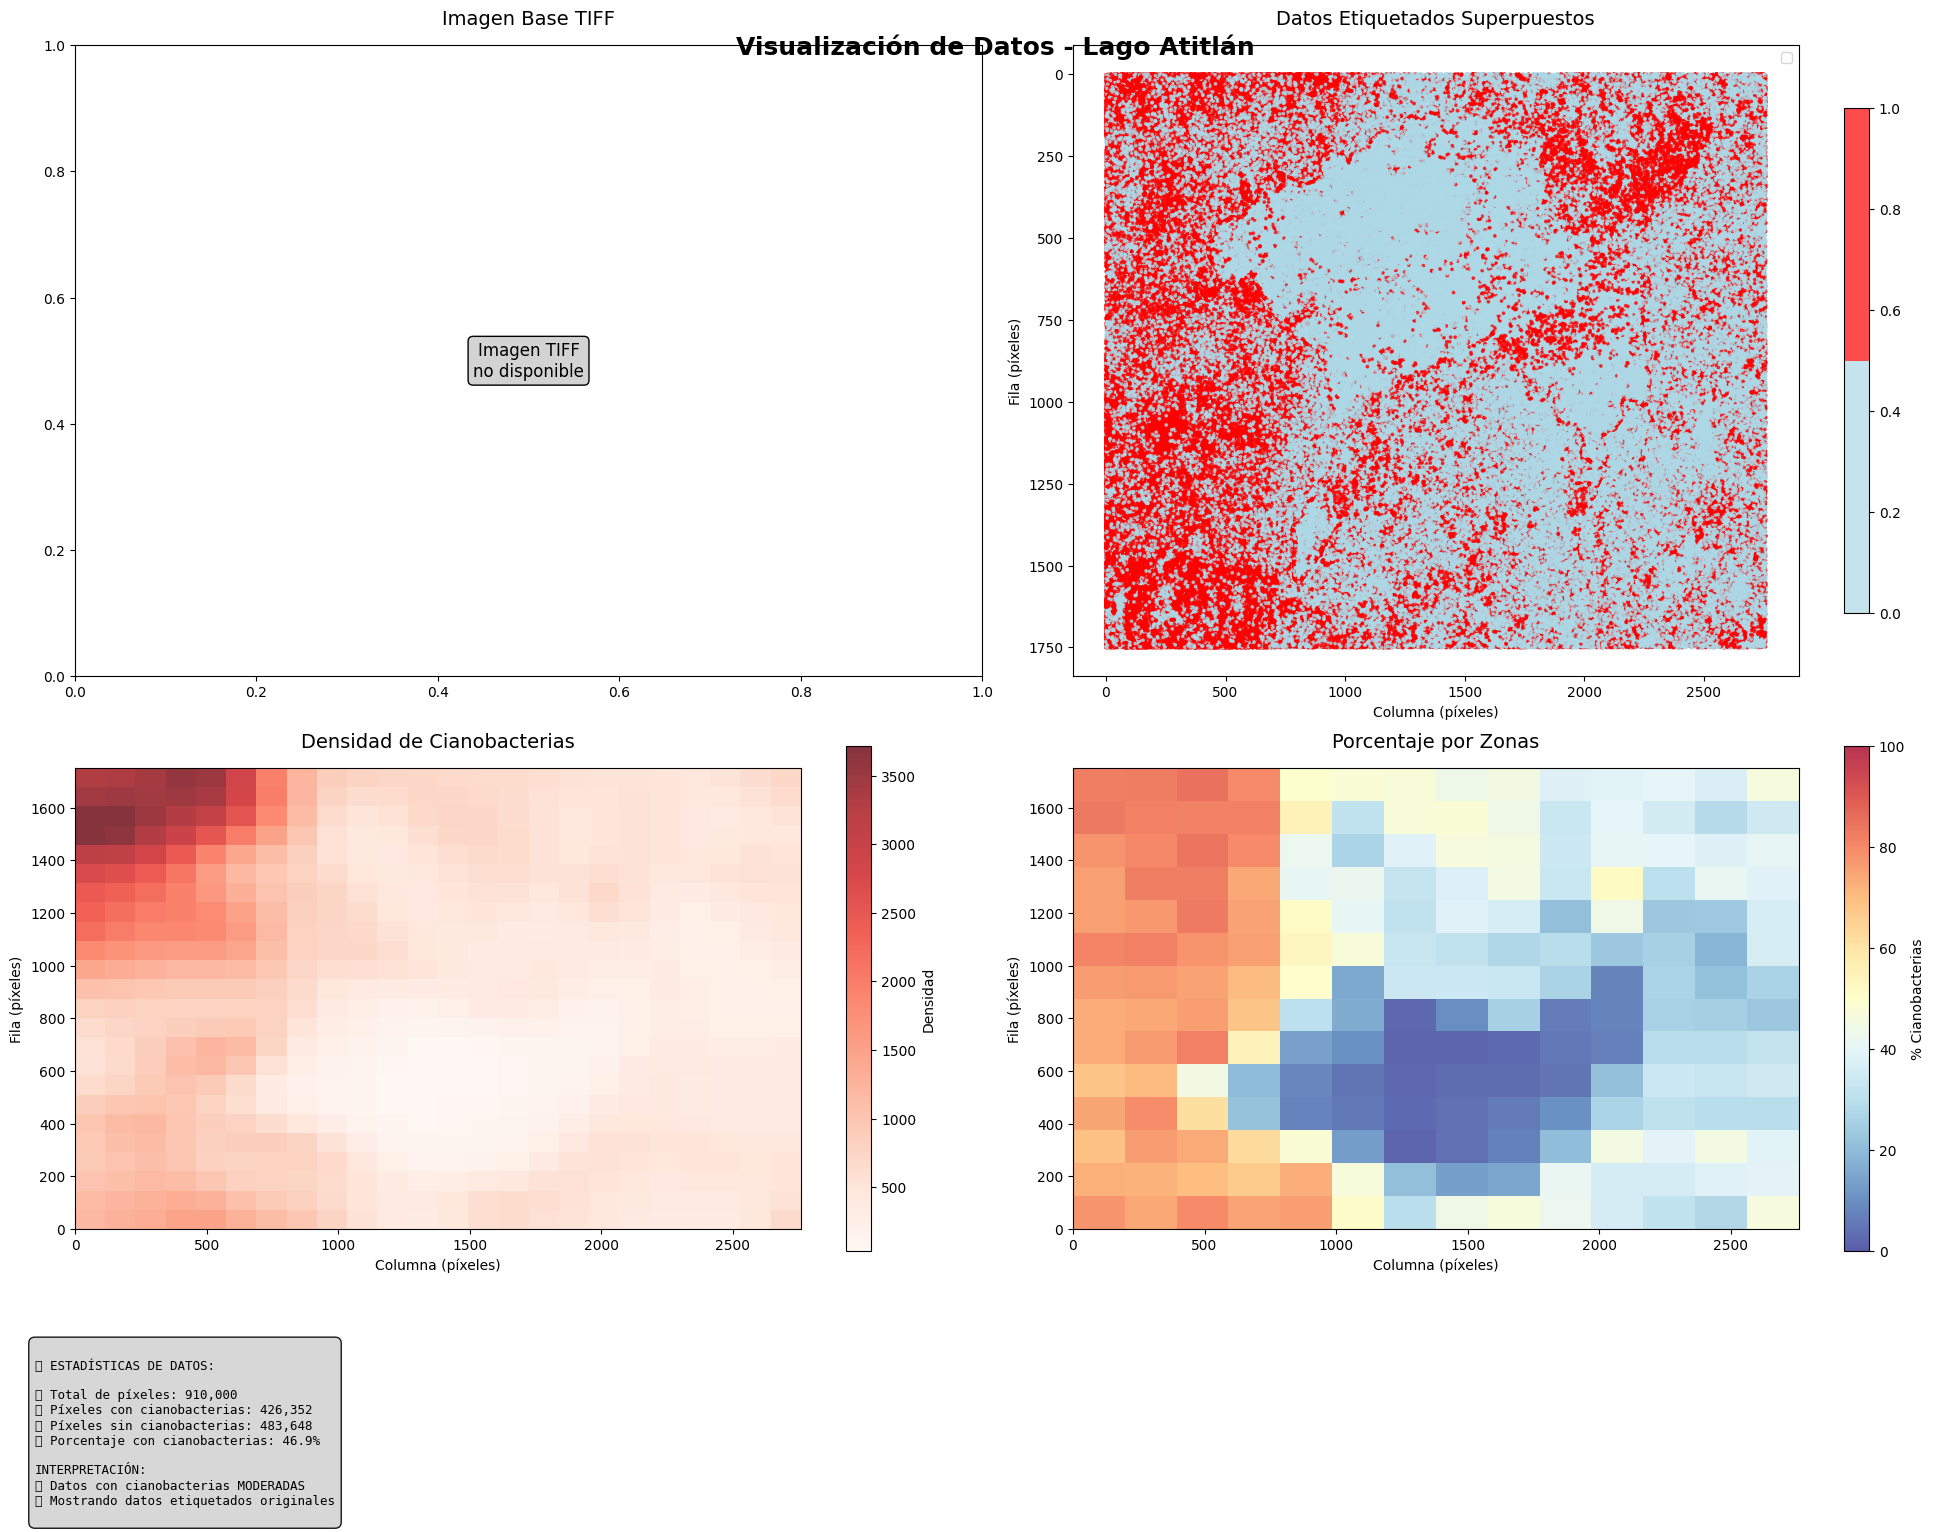

✅ Mapa creado exitosamente


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Intentar importar rasterio para TIFF geoespaciales
try:
    import rasterio
    from rasterio.plot import show
    RASTERIO_AVAILABLE = True
    print("✅ Rasterio disponible - Soporte completo para TIFF geoespaciales")
except ImportError:
    RASTERIO_AVAILABLE = False
    print("⚠️  Rasterio no disponible - Usando PIL para TIFF básicos")

def cargar_imagen_base(ruta_imagen):
    """
    Carga la imagen base del lago (TIFF o otros formatos)
    Soporta tanto TIFF geoespaciales como imágenes regulares
    """
    try:
        # Intentar cargar con rasterio primero (para TIFF geoespaciales)
        if RASTERIO_AVAILABLE and ruta_imagen.lower().endswith(('.tif', '.tiff')):
            print("📍 Cargando imagen TIFF con información geoespacial...")
            with rasterio.open(ruta_imagen) as src:
                # Leer todas las bandas
                imagen_array = src.read()
                
                # Obtener información geoespacial
                bounds = src.bounds
                transform = src.transform
                crs = src.crs
                
                print(f"   🗺️  CRS: {crs}")
                print(f"   📏 Bounds: {bounds}")
                print(f"   📐 Shape: {imagen_array.shape}")
                
                # Si tiene múltiples bandas, reorganizar para matplotlib (Height, Width, Bands)
                if len(imagen_array.shape) == 3 and imagen_array.shape[0] > 1:
                    # Tomar las primeras 3 bandas para RGB o usar la primera si es una sola banda
                    if imagen_array.shape[0] >= 3:
                        imagen_rgb = np.transpose(imagen_array[:3], (1, 2, 0))
                    else:
                        imagen_rgb = imagen_array[0]
                else:
                    imagen_rgb = np.squeeze(imagen_array)
                
                # Normalizar valores si es necesario
                if imagen_rgb.dtype in [np.uint16, np.float32, np.float64]:
                    # Normalizar a 0-255 para visualización
                    vmin, vmax = np.percentile(imagen_rgb, [2, 98])
                    imagen_rgb = np.clip((imagen_rgb - vmin) / (vmax - vmin) * 255, 0, 255).astype(np.uint8)
                
                return imagen_rgb, bounds, transform, crs
        
        # Fallback a PIL para otros formatos o si rasterio no está disponible
        print("🖼️  Cargando imagen con PIL...")
        imagen = Image.open(ruta_imagen)
        imagen_array = np.array(imagen)
        
        return imagen_array, None, None, None
        
    except Exception as e:
        print(f"❌ Error cargando imagen: {e}")
        return None, None, None, None

def crear_mapa_simple(datos, ruta_imagen_base, titulo="Visualización de Datos - Lago Atitlán"):
    """
    Crea mapas simples mostrando solo los datos sobre la imagen base
    SIN usar modelo ni scaler - solo visualización de datos existentes
    """
    print("🗺️  CREANDO MAPAS SIMPLES...")
    
    # 1. Cargar imagen base
    resultado_carga = cargar_imagen_base(ruta_imagen_base)
    if resultado_carga[0] is not None:
        imagen_base, bounds, transform, crs = resultado_carga
        tiene_georreferencia = bounds is not None
    else:
        imagen_base, bounds, transform, crs = None, None, None, None
        tiene_georreferencia = False
    
    # 2. Preparar datos para visualización
    datos_viz = datos.copy()
    
    # Si hay columna 'etiqueta', usarla para colorear
    tiene_etiquetas = 'etiqueta' in datos.columns
    
    # Crear figura con subplots
    if tiene_etiquetas:
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        axes = np.array([axes])  # Para mantener consistencia
    
    fig.suptitle(titulo, fontsize=18, fontweight='bold', y=0.95)
    
    # --- MAPA 1: Imagen base TIFF ---
    ax_idx = 0
    if imagen_base is not None:
        if tiene_georreferencia and RASTERIO_AVAILABLE:
            # Mostrar con coordenadas geográficas reales
            extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
            axes.flat[ax_idx].imshow(imagen_base, extent=extent)
            axes.flat[ax_idx].set_xlabel('Longitud')
            axes.flat[ax_idx].set_ylabel('Latitud')
            axes.flat[ax_idx].set_title('Imagen Base TIFF (Georreferenciada)', fontsize=14, pad=15)
        else:
            # Mostrar sin georreferencia
            axes.flat[ax_idx].imshow(imagen_base)
            axes.flat[ax_idx].set_xlabel('Columnas (píxeles)')
            axes.flat[ax_idx].set_ylabel('Filas (píxeles)')
            axes.flat[ax_idx].set_title('Imagen Base TIFF', fontsize=14, pad=15)
    else:
        axes.flat[ax_idx].text(0.5, 0.5, 'Imagen TIFF\nno disponible', 
                       ha='center', va='center', transform=axes.flat[ax_idx].transAxes,
                       fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        axes.flat[ax_idx].set_title('Imagen Base TIFF', fontsize=14, pad=15)
    
    # --- MAPA 2: Distribución de puntos de datos ---
    ax_idx = 1
    if imagen_base is not None and tiene_georreferencia:
        # Mostrar imagen base con transparencia
        axes.flat[ax_idx].imshow(imagen_base, extent=extent, alpha=0.6)
        
        if tiene_etiquetas:
            # Colorear según etiquetas existentes
            datos_positivos = datos_viz[datos_viz['etiqueta'] == 1]
            datos_negativos = datos_viz[datos_viz['etiqueta'] == 0]
            
            # Convertir coordenadas si es posible
            if transform is not None and RASTERIO_AVAILABLE:
                try:
                    from rasterio.transform import xy
                    coords_pos = [xy(transform, row, col) for row, col in zip(datos_positivos['row'], datos_positivos['col'])]
                    coords_neg = [xy(transform, row, col) for row, col in zip(datos_negativos['row'], datos_negativos['col'])]
                    
                    if coords_pos:
                        x_pos, y_pos = zip(*coords_pos)
                        axes.flat[ax_idx].scatter(x_pos, y_pos, c='red', alpha=0.8, s=5, label='Con Cianobacterias')
                    
                    if coords_neg:
                        x_neg, y_neg = zip(*coords_neg)
                        axes.flat[ax_idx].scatter(x_neg, y_neg, c='lightblue', alpha=0.6, s=2, label='Sin Cianobacterias')
                    
                    axes.flat[ax_idx].set_xlabel('Longitud')
                    axes.flat[ax_idx].set_ylabel('Latitud')
                except:
                    # Fallback a coordenadas de píxeles
                    axes.flat[ax_idx].scatter(datos_negativos['col'], datos_negativos['row'], 
                                     c='lightblue', alpha=0.6, s=2, label='Sin Cianobacterias')
                    axes.flat[ax_idx].scatter(datos_positivos['col'], datos_positivos['row'], 
                                     c='red', alpha=0.8, s=5, label='Con Cianobacterias')
                    axes.flat[ax_idx].set_xlabel('Columna (píxeles)')
                    axes.flat[ax_idx].set_ylabel('Fila (píxeles)')
                    axes.flat[ax_idx].invert_yaxis()
            else:
                # Usar coordenadas de píxeles
                axes.flat[ax_idx].scatter(datos_negativos['col'], datos_negativos['row'], 
                                 c='lightblue', alpha=0.6, s=2, label='Sin Cianobacterias')
                axes.flat[ax_idx].scatter(datos_positivos['col'], datos_positivos['row'], 
                                 c='red', alpha=0.8, s=5, label='Con Cianobacterias')
                axes.flat[ax_idx].set_xlabel('Columna (píxeles)')
                axes.flat[ax_idx].set_ylabel('Fila (píxeles)')
                axes.flat[ax_idx].invert_yaxis()
        else:
            # Sin etiquetas, mostrar todos los puntos igual
            axes.flat[ax_idx].scatter(datos_viz['col'], datos_viz['row'], 
                             c='blue', alpha=0.7, s=2, label='Puntos de datos')
            axes.flat[ax_idx].set_xlabel('Columna (píxeles)')
            axes.flat[ax_idx].set_ylabel('Fila (píxeles)')
            axes.flat[ax_idx].invert_yaxis()
    else:
        # Sin imagen base
        if tiene_etiquetas:
            scatter = axes.flat[ax_idx].scatter(datos_viz['col'], datos_viz['row'], 
                                       c=datos_viz['etiqueta'], 
                                       cmap=ListedColormap(['lightblue', 'red']),
                                       alpha=0.7, s=3)
            plt.colorbar(scatter, ax=axes.flat[ax_idx], shrink=0.8)
        else:
            axes.flat[ax_idx].scatter(datos_viz['col'], datos_viz['row'], 
                             c='blue', alpha=0.7, s=2)
        
        axes.flat[ax_idx].set_xlabel('Columna (píxeles)')
        axes.flat[ax_idx].set_ylabel('Fila (píxeles)')
        axes.flat[ax_idx].invert_yaxis()
    
    if tiene_etiquetas:
        axes.flat[ax_idx].set_title('Datos Etiquetados Superpuestos', fontsize=14, pad=15)
        axes.flat[ax_idx].legend(loc='upper right')
    else:
        axes.flat[ax_idx].set_title('Distribución de Puntos de Datos', fontsize=14, pad=15)
    
    # Si hay etiquetas, crear mapas adicionales
    if tiene_etiquetas:
        # --- MAPA 3: Densidad de detecciones positivas ---
        ax_idx = 2
        datos_positivos = datos_viz[datos_viz['etiqueta'] == 1]
        crear_mapa_densidad_simple(axes.flat[ax_idx], datos_positivos, datos_viz)
        axes.flat[ax_idx].set_title('Densidad de Cianobacterias', fontsize=14, pad=15)
        
        # --- MAPA 4: Estadísticas por zonas ---
        ax_idx = 3
        crear_mapa_estadisticas_zonas(axes.flat[ax_idx], datos_viz)
    
    # Agregar estadísticas
    agregar_estadisticas_simples(fig, datos_viz, tiene_georreferencia, crs, tiene_etiquetas)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15 if tiene_etiquetas else 0.1)
    
    return fig, datos_viz

def crear_mapa_densidad_simple(ax, datos_positivos, datos_viz):
    """
    Crea un mapa de densidad simple usando histogram2d
    """
    if len(datos_positivos) > 0:
        x_bins = np.linspace(datos_viz['col'].min(), datos_viz['col'].max(), 25)
        y_bins = np.linspace(datos_viz['row'].min(), datos_viz['row'].max(), 25)
        
        hist, xedges, yedges = np.histogram2d(datos_positivos['col'], datos_positivos['row'], 
                                            bins=[x_bins, y_bins])
        
        # Suavizar un poco el histograma si scipy está disponible
        try:
            from scipy.ndimage import gaussian_filter
            hist_smooth = gaussian_filter(hist, sigma=1)
        except ImportError:
            hist_smooth = hist
        
        im = ax.imshow(hist_smooth.T, origin='lower', 
                      extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                      cmap='Reds', alpha=0.8)
        
        plt.colorbar(im, ax=ax, shrink=0.8, label='Densidad')
        ax.set_xlabel('Columna (píxeles)')
        ax.set_ylabel('Fila (píxeles)')
    else:
        ax.text(0.5, 0.5, 'No hay\ndetecciones positivas', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Columna (píxeles)')
        ax.set_ylabel('Fila (píxeles)')

def crear_mapa_estadisticas_zonas(ax, datos_viz):
    """
    Crea un mapa simple de estadísticas por zonas
    """
    if 'etiqueta' not in datos_viz.columns:
        ax.text(0.5, 0.5, 'Sin etiquetas\ndisponibles', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Estadísticas por Zonas', fontsize=14, pad=15)
        return
    
    # Dividir en grid y calcular estadísticas
    x_min, x_max = datos_viz['col'].min(), datos_viz['col'].max()
    y_min, y_max = datos_viz['row'].min(), datos_viz['row'].max()
    
    x_bins = np.linspace(x_min, x_max, 15)
    y_bins = np.linspace(y_min, y_max, 15)
    
    # Crear grid de estadísticas
    stats_grid = np.zeros((len(y_bins)-1, len(x_bins)-1))
    
    for i in range(len(y_bins)-1):
        for j in range(len(x_bins)-1):
            # Encontrar puntos en esta celda
            mask = ((datos_viz['col'] >= x_bins[j]) & (datos_viz['col'] < x_bins[j+1]) &
                   (datos_viz['row'] >= y_bins[i]) & (datos_viz['row'] < y_bins[i+1]))
            
            puntos_celda = datos_viz[mask]
            if len(puntos_celda) > 0:
                # Porcentaje de positivos en esta celda
                stats_grid[i, j] = puntos_celda['etiqueta'].mean() * 100
            else:
                stats_grid[i, j] = np.nan
    
    # Mostrar grid
    im = ax.imshow(stats_grid, origin='lower', 
                  extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                  cmap='RdYlBu_r', alpha=0.8, vmin=0, vmax=100)
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='% Cianobacterias')
    ax.set_title('Porcentaje por Zonas', fontsize=14, pad=15)
    ax.set_xlabel('Columna (píxeles)')
    ax.set_ylabel('Fila (píxeles)')

def agregar_estadisticas_simples(fig, datos_viz, tiene_georreferencia, crs, tiene_etiquetas):
    """
    Agrega estadísticas simples al mapa
    """
    total_pixeles = len(datos_viz)
    
    geo_info = f"""
🗺️  INFORMACIÓN GEOESPACIAL:
{'✅ Imagen georreferenciada' if tiene_georreferencia else '⚠️  Sin georreferencia'}
{f'📍 Sistema: {crs}' if crs else ''}
""" if tiene_georreferencia else ""
    
    if tiene_etiquetas:
        pixeles_positivos = len(datos_viz[datos_viz['etiqueta'] == 1])
        pixeles_negativos = len(datos_viz[datos_viz['etiqueta'] == 0])
        porcentaje_positivos = (pixeles_positivos / total_pixeles) * 100 if total_pixeles > 0 else 0
        
        stats_text = f"""{geo_info}
📊 ESTADÍSTICAS DE DATOS:

🔢 Total de píxeles: {total_pixeles:,}
🔴 Píxeles con cianobacterias: {pixeles_positivos:,}
🔵 Píxeles sin cianobacterias: {pixeles_negativos:,}
📈 Porcentaje con cianobacterias: {porcentaje_positivos:.1f}%

INTERPRETACIÓN:
{'🟢 Datos con POCAS cianobacterias' if porcentaje_positivos < 20 else '🟡 Datos con cianobacterias MODERADAS' if porcentaje_positivos < 50 else '🔴 Datos con MUCHAS cianobacterias'}
✅ Mostrando datos etiquetados originales
"""
    else:
        # Calcular algunas estadísticas básicas de las características numéricas
        columnas_numericas = datos_viz.select_dtypes(include=[np.number]).columns
        columnas_numericas = [col for col in columnas_numericas if col not in ['row', 'col']]
        
        stats_text = f"""{geo_info}
📊 ESTADÍSTICAS DE DATOS:

🔢 Total de píxeles: {total_pixeles:,}
📋 Características numéricas: {len(columnas_numericas)}
📅 Fechas únicas: {datos_viz['fecha'].nunique() if 'fecha' in datos_viz.columns else 'N/A'}

📈 CARACTERÍSTICAS PRINCIPALES:
{chr(10).join([f'   {col}: μ={datos_viz[col].mean():.3f}, σ={datos_viz[col].std():.3f}' 
               for col in columnas_numericas[:5]])}

⚠️  Sin etiquetas - Solo visualización de datos
"""
    
    # Agregar texto en una zona vacía
    fig.text(0.02, 0.02, stats_text, fontsize=9, 
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9),
             verticalalignment='bottom', family='monospace')

def visualizar_mapa_simple(datos, ruta_imagen_base=None):
    """
    Función principal para visualizar solo los mapas sin predicciones
    """
    print("\n=== CREANDO VISUALIZACIÓN SIMPLE DE MAPAS ===")
    print("🔍 Sin usar modelo ni scaler - Solo mostrando datos existentes")
    
    # Verificar columnas básicas requeridas
    columnas_requeridas = ['row', 'col']
    columnas_faltantes = [col for col in columnas_requeridas if col not in datos.columns]
    
    if columnas_faltantes:
        print(f"❌ Error: Faltan columnas requeridas: {columnas_faltantes}")
        print("💡 Los datos deben tener al menos las columnas 'row' y 'col'")
        return None, None
    
    # Crear mapa principal
    fig, datos_viz = crear_mapa_simple(datos, ruta_imagen_base)
    
    if fig is not None:
        plt.show()
        print("✅ Mapa creado exitosamente")
        
        # Guardar si se desea
        respuesta = input("\n¿Deseas guardar los mapas? (s/n): ").lower().strip()
        if respuesta in ['s', 'si', 'y', 'yes']:
            nombre = input("Nombre del archivo (sin extensión): ").strip()
            if not nombre:
                nombre = "mapa_visualizacion"
            
            plt.figure(fig.number)
            plt.savefig(f"{nombre}.png", dpi=300, bbox_inches='tight')
            plt.savefig(f"{nombre}.pdf", bbox_inches='tight')
            print(f"✅ Mapas guardados como {nombre}.png y .pdf")
    
    return fig, datos_viz

# Ejemplo de uso:

fig, datos_viz = visualizar_mapa_simple(datos, ruta_imagen_base="./data/GIS/Atitlan/openEO_2025-05-23Z.tif")
